In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [4]:
df1 = pd.read_csv("all_data/btc_4h_binance.csv")
df2 = pd.read_csv("all_data/eth_4h_binance.csv")

In [5]:
df1.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote
0,2020-01-01 00:00:00,7195.24,7245.00,7175.46,7225.01,2833.749180,2.044590e+07,32476,1548.865619,1.117659e+07
1,2020-01-01 04:00:00,7225.00,7236.27,7199.11,7209.83,2061.295051,1.489018e+07,29991,1049.711236,7.582850e+06
2,2020-01-01 08:00:00,7209.83,7237.73,7180.00,7197.20,3166.654361,2.280732e+07,33507,1562.344314,1.125370e+07
3,2020-01-01 12:00:00,7197.20,7255.00,7196.15,7234.19,3492.537459,2.523556e+07,36549,2086.279119,1.507671e+07
4,2020-01-01 16:00:00,7234.20,7249.99,7214.00,7229.48,2980.583291,2.156177e+07,32877,1673.060594,1.210416e+07


In [6]:
df1.shape

(13907, 10)

In [7]:
df2.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote
0,2020-01-01 00:00:00,129.16,130.98,128.68,130.20,31685.73908,4.116595e+06,13253,15214.86403,1.975671e+06
1,2020-01-01 04:00:00,130.21,130.75,130.11,130.24,15457.58966,2.015694e+06,9605,7891.80272,1.029166e+06
2,2020-01-01 08:00:00,130.24,131.87,129.87,130.74,27822.94195,3.635352e+06,14330,14158.39603,1.850548e+06
3,2020-01-01 12:00:00,130.74,132.40,130.70,132.08,24010.28657,3.162056e+06,12981,13549.53039,1.784206e+06
4,2020-01-01 16:00:00,132.08,133.05,131.57,131.86,20158.22421,2.665641e+06,11703,10624.65770,1.405557e+06


In [8]:
df1.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'quote_volume',
       'num_trades', 'taker_buy_volume', 'taker_buy_quote'],
      dtype='object')

In [9]:
df1.isna().sum()

date                0
open                0
high                0
low                 0
close               0
volume              0
quote_volume        0
num_trades          0
taker_buy_volume    0
taker_buy_quote     0
dtype: int64

In [10]:
df1.duplicated().sum()

np.int64(0)

In [11]:
df2['date']=pd.to_datetime(df2['date'])

In [12]:
df2.duplicated().sum()

np.int64(0)

In [13]:
df1["type"]='BTC'

In [14]:
df1.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,type
0,2020-01-01 00:00:00,7195.24,7245.00,7175.46,7225.01,2833.749180,2.044590e+07,32476,1548.865619,1.117659e+07,BTC
1,2020-01-01 04:00:00,7225.00,7236.27,7199.11,7209.83,2061.295051,1.489018e+07,29991,1049.711236,7.582850e+06,BTC
2,2020-01-01 08:00:00,7209.83,7237.73,7180.00,7197.20,3166.654361,2.280732e+07,33507,1562.344314,1.125370e+07,BTC
3,2020-01-01 12:00:00,7197.20,7255.00,7196.15,7234.19,3492.537459,2.523556e+07,36549,2086.279119,1.507671e+07,BTC
4,2020-01-01 16:00:00,7234.20,7249.99,7214.00,7229.48,2980.583291,2.156177e+07,32877,1673.060594,1.210416e+07,BTC


In [15]:
df2["type"]='ETH'

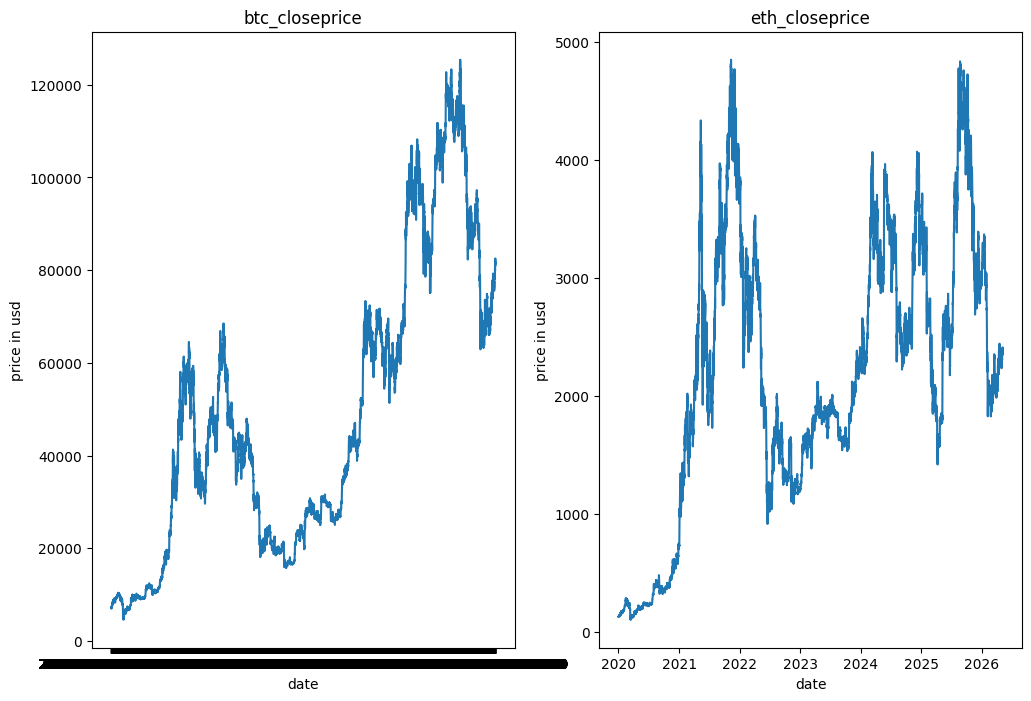

In [16]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.lineplot(x='date',data=df1,y='close')
plt.title("btc_closeprice")
plt.ylabel("price in usd")
plt.subplot(1,2,2)
sns.lineplot(x='date',data=df2,y='close')
plt.title("eth_closeprice")
plt.ylabel("price in usd")
plt.show()

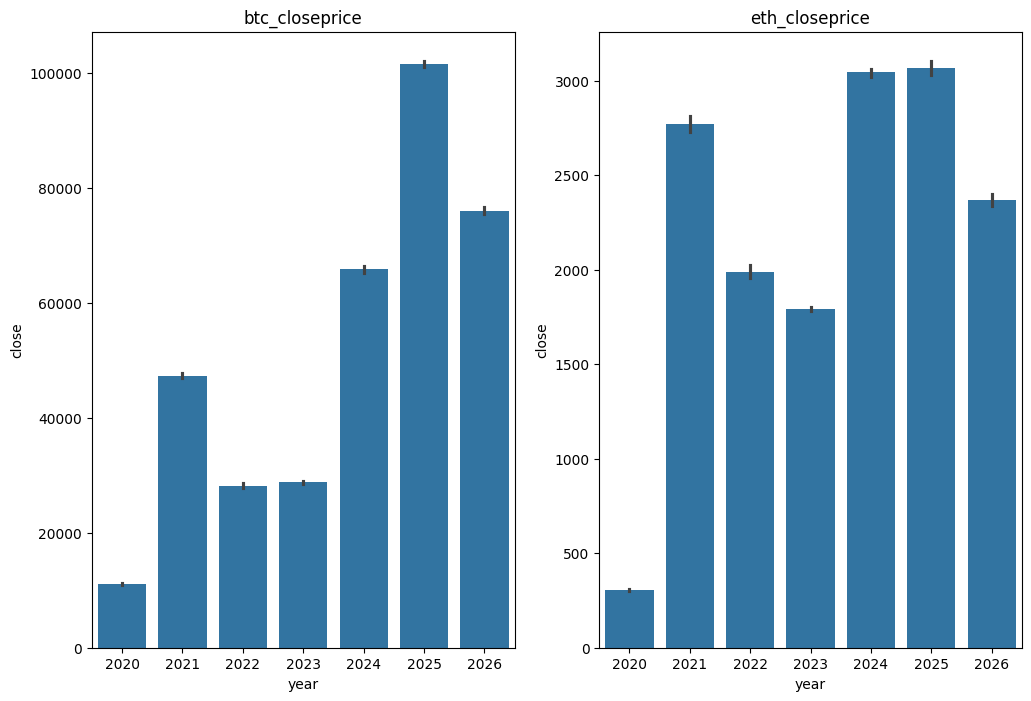

In [18]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
df1["date"] = pd.to_datetime(df1["date"])
df1["year"] = df1["date"].dt.year
sns.barplot(x='year',data=df1,y='close')
plt.title("btc_closeprice")
plt.subplot(1,2,2)
df2["year"]=df2["date"].dt.year
sns.barplot(x='year',data=df2,y='close')
plt.title("eth_closeprice")
plt.show()

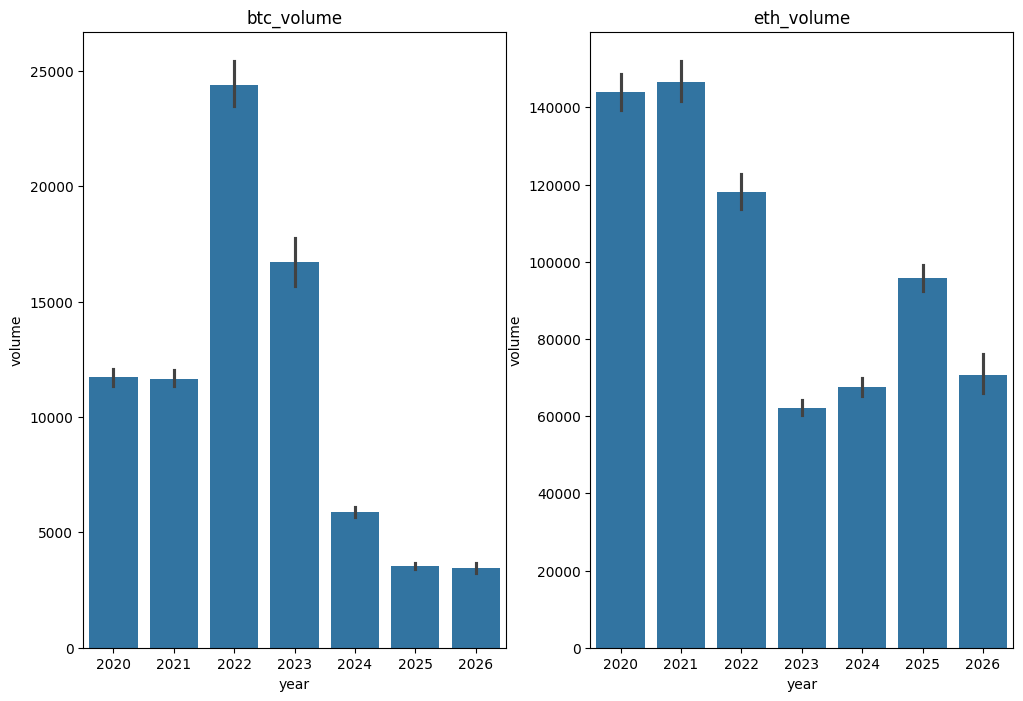

In [19]:

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
df1["year"] = df1["date"].dt.year
sns.barplot(x='year',data=df1,y='volume')
plt.title("btc_volume")
plt.subplot(1,2,2)
df2["year"]=df2["date"].dt.year
sns.barplot(x='year',data=df2,y='volume')
plt.title("eth_volume")
plt.show()

In [20]:
df1[['open','high','low','close','volume','quote_volume']].describe()


,open,high,low,close,volume,quote_volume
count,13907.000000,13907.000000,13907.000000,13907.000000,13907.000000,1.390700e+04
mean,48726.014900,49116.150362,48313.170115,48731.390919,11832.461524,3.861965e+08
std,31319.202265,31498.770952,31128.024982,31318.458148,15953.032724,3.868618e+08
min,4565.630000,4950.000000,3782.130000,4565.590000,5.887034,2.922260e+05
25%,22984.890000,23184.820000,22803.945000,22988.020000,3503.816260,1.411406e+08
50%,42132.520000,42493.200000,41739.000000,42135.330000,6651.456580,2.688515e+08
75%,67855.305000,68363.155000,67366.930000,67856.005000,12917.239809,4.936863e+08
max,125410.800000,126199.630000,124800.000000,125410.810000,284711.694213,5.457624e+09


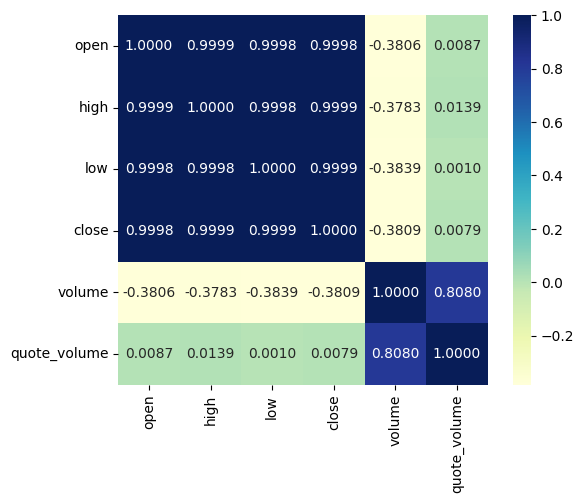

In [21]:
corr1=df1[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr1,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show() #as i predicted above the relation between volume and close price is negative as when volume is high thats mean closing price was low so alot of people buy

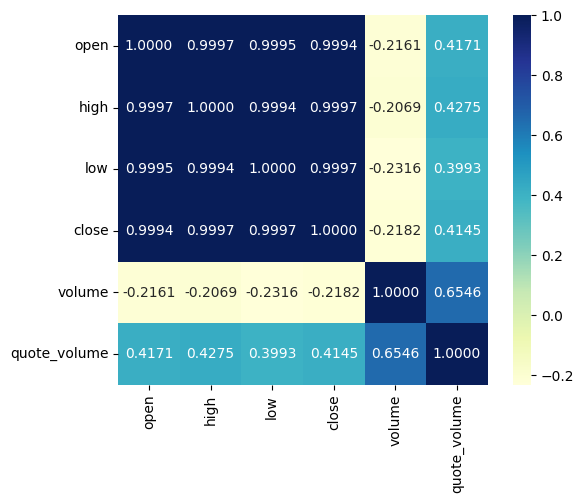

In [22]:
corr2=df2[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr2,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

In [23]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025]:
    btc_year = df1[df1['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_year['date'],
        open=btc_year['open'],
        high=btc_year['high'],
        low=btc_year['low'],
        close=btc_year['close']
    )])

    fig.update_layout(title=f'BTC Candlestick Chart - {year}')
    fig.show()"""

"for year in [2020, 2021, 2022, 2023, 2024,2025]:\n    btc_year = df1[df1['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=btc_year['date'],\n        open=btc_year['open'],\n        high=btc_year['high'],\n        low=btc_year['low'],\n        close=btc_year['close']\n    )])\n\n    fig.update_layout(title=f'BTC Candlestick Chart - {year}')\n    fig.show()"

In [24]:
"""import plotly.graph_objects as go

years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
}
for year, months in years_months.items():
    btc_filtered = df1[(df1['date'].dt.year == year) & (df1['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_filtered['date'],
        open=btc_filtered['open'],
        high=btc_filtered['high'],
        low=btc_filtered['low'],
        close=btc_filtered['close']
    )])

    fig.update_layout(title=f'BTC Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()"""

"import plotly.graph_objects as go\n\nyears_months = {\n    2020: [3, 8, 12],\n    2021: [1, 4, 11],\n    2022: [1, 5, 11],\n    2023: [1, 3, 10],\n    2024: [1, 3, 11],\n}\nfor year, months in years_months.items():\n    btc_filtered = df1[(df1['date'].dt.year == year) & (df1['date'].dt.month.isin(months))]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=btc_filtered['date'],\n        open=btc_filtered['open'],\n        high=btc_filtered['high'],\n        low=btc_filtered['low'],\n        close=btc_filtered['close']\n    )])\n\n    fig.update_layout(title=f'BTC Candlestick - {year} (Jan, Jun, Dec)')\n    fig.show()"

In [25]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025]:
    eth_year = df2[df2['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=eth_year['date'],
        open=eth_year['open'],
        high=eth_year['high'],
        low=eth_year['low'],
        close=eth_year['close']
    )])

    fig.update_layout(title=f'ETH Candlestick Chart - {year}')
    fig.show() """

"for year in [2020, 2021, 2022, 2023, 2024,2025]:\n    eth_year = df2[df2['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=eth_year['date'],\n        open=eth_year['open'],\n        high=eth_year['high'],\n        low=eth_year['low'],\n        close=eth_year['close']\n    )])\n\n    fig.update_layout(title=f'ETH Candlestick Chart - {year}')\n    fig.show() "

In [26]:
"""import plotly.graph_objects as go

years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
}
for year, months in years_months.items():
    eth_filtered = df2[(df2['date'].dt.year == year) & (df2['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=eth_filtered['date'],
        open=eth_filtered['open'],
        high=eth_filtered['high'],
        low=eth_filtered['low'],
        close=eth_filtered['close']
    )])

    fig.update_layout(title=f'ETH Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()"""

"import plotly.graph_objects as go\n\nyears_months = {\n    2020: [3, 8, 12],\n    2021: [1, 4, 11],\n    2022: [1, 5, 11],\n    2023: [1, 3, 10],\n    2024: [1, 3, 11],\n}\nfor year, months in years_months.items():\n    eth_filtered = df2[(df2['date'].dt.year == year) & (df2['date'].dt.month.isin(months))]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=eth_filtered['date'],\n        open=eth_filtered['open'],\n        high=eth_filtered['high'],\n        low=eth_filtered['low'],\n        close=eth_filtered['close']\n    )])\n\n    fig.update_layout(title=f'ETH Candlestick - {year} (Jan, Jun, Dec)')\n    fig.show()"

In [27]:
df1.drop(columns='year',inplace=True)
df2.drop(columns='year',inplace=True)

## Feature engeering

In [28]:
df1["candle_body"]=df1['close']-df1['open']/ df1['open']
df2['candle_body']=df2['close']-df2['open']/ df1['open']


In [29]:
df1.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,type,candle_body
0,2020-01-01 00:00:00,7195.24,7245.00,7175.46,7225.01,2833.749180,2.044590e+07,32476,1548.865619,1.117659e+07,BTC,7224.01
1,2020-01-01 04:00:00,7225.00,7236.27,7199.11,7209.83,2061.295051,1.489018e+07,29991,1049.711236,7.582850e+06,BTC,7208.83
2,2020-01-01 08:00:00,7209.83,7237.73,7180.00,7197.20,3166.654361,2.280732e+07,33507,1562.344314,1.125370e+07,BTC,7196.20
3,2020-01-01 12:00:00,7197.20,7255.00,7196.15,7234.19,3492.537459,2.523556e+07,36549,2086.279119,1.507671e+07,BTC,7233.19
4,2020-01-01 16:00:00,7234.20,7249.99,7214.00,7229.48,2980.583291,2.156177e+07,32877,1673.060594,1.210416e+07,BTC,7228.48


In [30]:
df1['high_low_range']=df1['high']-df1['low']/ df1['close']
df2['high_low_range']=df2['high']-df2['low']/ df2['close']

In [31]:
df1['MA_7']=df1['close'].rolling(window=7).mean()
df2['MA_7']=df2['close'].rolling(window=7).mean()

In [32]:
df1['MA_30']=df1['close'].rolling(window=30).mean()
df2['MA_30']=df2['close'].rolling(window=30).mean()

In [33]:
  df1['ma7_ratio'] = df1['close'] / df1['MA_7'] - 1
  df1['ma30_ratio'] = df1['close'] / df1['MA_30'] - 1

  df2['ma7_ratio'] = df2['close'] / df2['MA_7'] - 1
  df2['ma30_ratio'] = df2['close'] / df2['MA_30'] - 1



In [34]:
df1.shape

(13907, 17)

In [36]:
df1['moving_1d'] = df1['close'].pct_change() * 100
df2['moving_1d'] = df2['close'].pct_change() * 100

In [37]:
df1["volatility_7"] = df1["moving_1d"].rolling(window=7).std()
df2["volatility_7"] = df2["moving_1d"].rolling(window=7).std()

In [38]:
df1["volume_MA7"] = df1["volume"].rolling(window=7).mean()
df1["volumespike"] = df1["volume"] / df1["volume_MA7"]
df2["volume_MA7"] = df2["volume"].rolling(window=7).mean()
df2["volumespike"] = df2["volume"] / df2["volume_MA7"]

In [39]:
df1.drop(columns='volume_MA7',inplace=True)
df2.drop(columns='volume_MA7',inplace=True)

In [40]:
df1["rolling_mean_30"] = df1["close"].rolling(window=30).mean()
df1["rolling_std_30"]  = df1["close"].rolling(window=30).std()
df1["z_score"] = (df1["close"] - df1["rolling_mean_30"]) / df1["rolling_std_30"]

df2["rolling_mean_30"] = df2["close"].rolling(window=30).mean()
df2["rolling_std_30"]  = df2["close"].rolling(window=30).std()
df2["z_score"] = (df2["close"] - df2["rolling_mean_30"]) / df2["rolling_std_30"]

In [41]:
df1.drop(columns='rolling_mean_30',inplace=True)
df2.drop(columns='rolling_mean_30',inplace=True)
df1.drop(columns='rolling_std_30',inplace=True)
df2.drop(columns='rolling_std_30',inplace=True)

In [42]:
# next 4H candle return (not tomorrow)
df1['next_close']   = df1['close'].shift(-1)
df1['next_return']  = (df1['next_close'] - df1['close']) / df1['close'] * 100

df2['next_close']   = df2['close'].shift(-1)
df2['next_return']  = (df2['next_close'] - df2['close']) / df2['close'] * 100

In [43]:
df1['taker_buy_ratio'] = df1['taker_buy_volume'] / df1['volume']
df1['price_position']  = (df1['close'] - df1['low']) / (df1['high'] - df1['low'])
df1['momentum_7']      = df1['close'] / df1['close'].shift(7) - 1

df2['taker_buy_ratio'] = df2['taker_buy_volume'] / df2['volume']
df2['price_position']  = (df2['close'] - df2['low']) / (df2['high'] - df2['low'])
df2['momentum_7']      = df2['close'] / df2['close'].shift(7) - 1

In [44]:
df1['taker_sell_ratio']  = 1 - df1['taker_buy_ratio']  # bearish pressure
df1['negative_momentum'] = df1['momentum_7'].apply(lambda x: x if x < 0 else 0)  # negative side
df1['down_days_7']       = (df1['moving_1d'] < 0).rolling(7).sum()  # count down days

df2['taker_sell_ratio']  = 1 - df2['taker_buy_ratio']  # bearish pressure
df2['negative_momentum'] = df2['momentum_7'].apply(lambda x: x if x < 0 else 0) # negative side
df2['down_days_7']       = (df2['moving_1d'] < 0).rolling(7).sum()  # count down days

In [45]:
df1['volatility_14'] = df1['moving_1d'].rolling(14).std()
df1['volatility_3']  = df1['moving_1d'].rolling(3).std()

df2['volatility_14'] = df2['moving_1d'].rolling(14).std()
df2['volatility_3']  = df2['moving_1d'].rolling(3).std()

In [46]:
q_low=df1['next_return'].quantile(0.30)
q_high=df1['next_return'].quantile(0.70)

df1['label'] = df1['next_return'].apply(
    lambda x: "Big Up" if x > q_high else ("Big Down" if x < q_low else "Stable")
)





In [47]:
q_low = df1['next_return'].quantile(0.30)
q_high = df1['next_return'].quantile(0.70)
df1['label'] = df1['next_return'].apply(lambda x: 'Bigup' if x > q_high else ('Bigdown' if x < q_low else 'Stable'))

q_low = df2['next_return'].quantile(0.30)
q_high = df2['next_return'].quantile(0.70)
df2['label'] = df2['next_return'].apply(lambda x: 'Bigup' if x > q_high else ('Bigdown' if x < q_low else 'Stable'))

In [48]:
df1["label"].value_counts()

label
Stable     5563
Bigup      4172
Bigdown    4172
Name: count, dtype: int64

In [49]:
df1.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-01 00:00:00,7195.24,7245.00,7175.46,7225.01,2833.749180,2.044590e+07,32476,1548.865619,1.117659e+07,...,-0.210104,0.546578,0.712540,NaN,0.453422,0.0,NaN,NaN,NaN,Stable
1,2020-01-01 04:00:00,7225.00,7236.27,7199.11,7209.83,2061.295051,1.489018e+07,29991,1049.711236,7.582850e+06,...,-0.175178,0.509248,0.288482,NaN,0.490752,0.0,NaN,NaN,NaN,Stable
2,2020-01-01 08:00:00,7209.83,7237.73,7180.00,7197.20,3166.654361,2.280732e+07,33507,1562.344314,1.125370e+07,...,0.513950,0.493374,0.297939,NaN,0.506626,0.0,NaN,NaN,NaN,Bigup
3,2020-01-01 12:00:00,7197.20,7255.00,7196.15,7234.19,3492.537459,2.523556e+07,36549,2086.279119,1.507671e+07,...,-0.065107,0.597353,0.646389,NaN,0.402647,0.0,NaN,NaN,0.408324,Stable
4,2020-01-01 16:00:00,7234.20,7249.99,7214.00,7229.48,2980.583291,2.156177e+07,32877,1673.060594,1.210416e+07,...,-0.396017,0.561320,0.430119,NaN,0.438680,0.0,NaN,NaN,0.370207,Bigdown


In [50]:
df2.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-01 00:00:00,129.16,130.98,128.68,130.20,31685.73908,4.116595e+06,13253,15214.86403,1.975671e+06,...,0.030722,0.480180,0.660870,NaN,0.519820,0.0,NaN,NaN,NaN,Stable
1,2020-01-01 04:00:00,130.21,130.75,130.11,130.24,15457.58966,2.015694e+06,9605,7891.80272,1.029166e+06,...,0.383907,0.510545,0.203125,NaN,0.489455,0.0,NaN,NaN,NaN,Stable
2,2020-01-01 08:00:00,130.24,131.87,129.87,130.74,27822.94195,3.635352e+06,14330,14158.39603,1.850548e+06,...,1.024935,0.508875,0.435000,NaN,0.491125,0.0,NaN,NaN,NaN,Bigup
3,2020-01-01 12:00:00,130.74,132.40,130.70,132.08,24010.28657,3.162056e+06,12981,13549.53039,1.784206e+06,...,-0.166566,0.564322,0.811765,NaN,0.435678,0.0,NaN,NaN,0.504003,Stable
4,2020-01-01 16:00:00,132.08,133.05,131.57,131.86,20158.22421,2.665641e+06,11703,10624.65770,1.405557e+06,...,-0.826634,0.527063,0.195946,NaN,0.472937,0.0,NaN,NaN,0.596324,Bigdown


In [51]:
print(df1.columns.tolist())

['date', 'open', 'high', 'low', 'close', 'volume', 'quote_volume', 'num_trades', 'taker_buy_volume', 'taker_buy_quote', 'type', 'candle_body', 'high_low_range', 'MA_7', 'MA_30', 'ma7_ratio', 'ma30_ratio', 'moving_1d', 'volatility_7', 'volumespike', 'z_score', 'next_close', 'next_return', 'taker_buy_ratio', 'price_position', 'momentum_7', 'taker_sell_ratio', 'negative_momentum', 'down_days_7', 'volatility_14', 'volatility_3', 'label']


In [53]:
from scipy.stats import skew, kurtosis
df1 = df1.dropna(subset=['next_return'])
skew2=skew(df1['next_return'])
print(skew2)

df2 = df2.dropna(subset=['next_return'])
skew21=skew(df2['next_return'])
print(skew21)

kurtosis1=kurtosis(df1['next_return'])
kurtosis2=kurtosis(df2['next_return'])
kurtosis1,kurtosis2

-0.38589446219898166
-0.3620921520178171


(np.float64(15.783381225751043), np.float64(10.070409604188816))

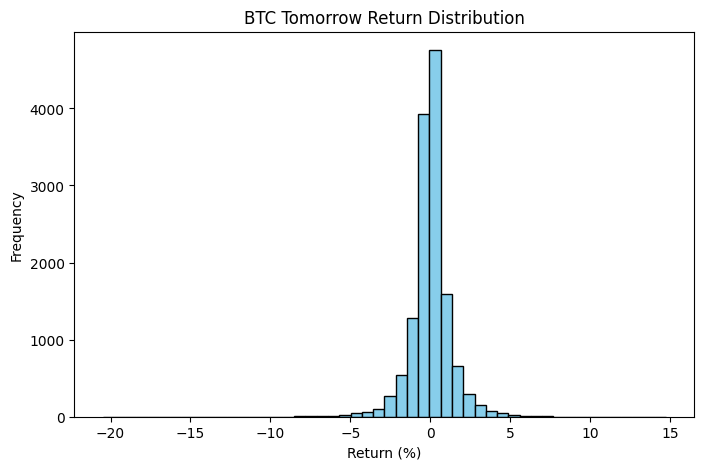

In [54]:
import matplotlib.pyplot as plt

# Example for BTC
plt.figure(figsize=(8,5))
plt.hist(df1['next_return'], bins=50, color='skyblue', edgecolor='black')
plt.title('BTC Tomorrow Return Distribution')
plt.xlabel('Return (%)')
plt.ylabel('Frequency')
plt.show()

C:\Users\ibrah\AppData\Local\Temp\ipykernel_28696\3497873697.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df1['next_return'], shade=True, color='orange')


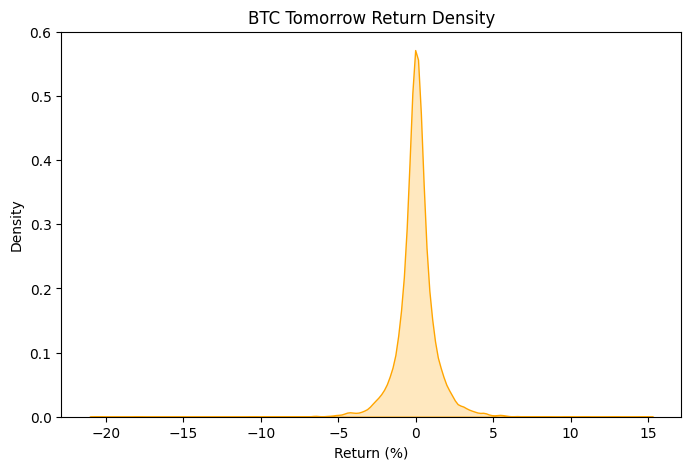

In [55]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(df1['next_return'], shade=True, color='orange')
plt.title('BTC Tomorrow Return Density')
plt.xlabel('Return (%)')
plt.show()

C:\Users\ibrah\AppData\Local\Temp\ipykernel_28696\2540195810.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df1['next_return'], shade=True, color='lightblue')


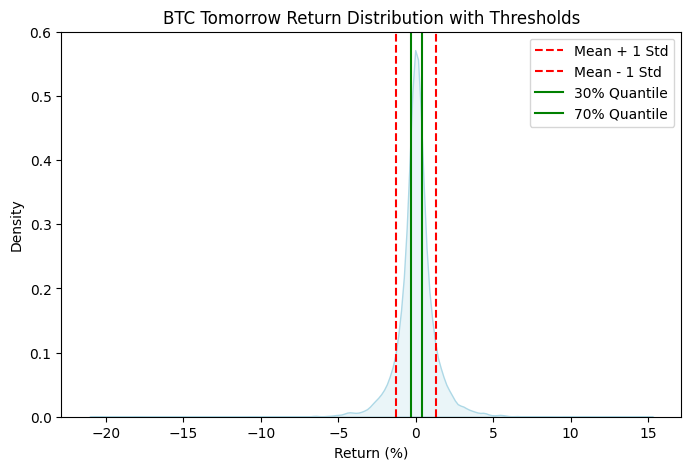

In [57]:
mean = df1['next_return'].mean()
std = df1['next_return'].std()
q_low = df1['next_return'].quantile(0.3)
q_high = df1['next_return'].quantile(0.7)

plt.figure(figsize=(8,5))
sns.kdeplot(df1['next_return'], shade=True, color='lightblue')

# Mean ± std thresholds
plt.axvline(mean + std, color='red', linestyle='--', label='Mean + 1 Std')
plt.axvline(mean - std, color='red', linestyle='--', label='Mean - 1 Std')

# Quantile thresholds
plt.axvline(q_low, color='green', linestyle='-', label='30% Quantile')
plt.axvline(q_high, color='green', linestyle='-', label='70% Quantile')

plt.title('BTC Tomorrow Return Distribution with Thresholds')
plt.xlabel('Return (%)')
plt.legend()
plt.show()

C:\Users\ibrah\AppData\Local\Temp\ipykernel_28696\2906818510.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df2['next_return'], shade=True, color='lightblue')


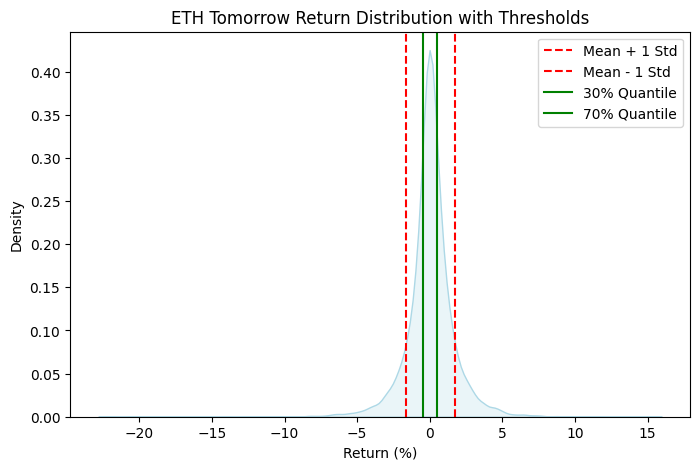

In [58]:
mean = df2['next_return'].mean()
std = df2['next_return'].std()
q_low = df2['next_return'].quantile(0.3)
q_high = df2['next_return'].quantile(0.7)

plt.figure(figsize=(8,5))
sns.kdeplot(df2['next_return'], shade=True, color='lightblue')

# Mean ± std thresholds
plt.axvline(mean + std, color='red', linestyle='--', label='Mean + 1 Std')
plt.axvline(mean - std, color='red', linestyle='--', label='Mean - 1 Std')

# Quantile thresholds
plt.axvline(q_low, color='green', linestyle='-', label='30% Quantile')
plt.axvline(q_high, color='green', linestyle='-', label='70% Quantile')

plt.title('ETH Tomorrow Return Distribution with Thresholds')
plt.xlabel('Return (%)')
plt.legend()
plt.show()

In [59]:
df1[30:35]

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
30,2020-01-06 00:00:00,7357.64,7580.00,7346.76,7540.90,13578.258656,1.016581e+08,90571,7253.706938,5.428938e+07,...,-0.437481,0.534215,0.832362,0.025399,0.465785,0.0,4.0,0.909539,1.899092,Bigdown
31,2020-01-06 04:00:00,7540.90,7554.61,7496.00,7507.91,4822.718155,3.628604e+07,44909,2533.851605,1.906445e+07,...,0.490283,0.525399,0.203208,0.004270,0.474601,0.0,5.0,0.924428,1.919602,Bigup
32,2020-01-06 08:00:00,7508.18,7582.27,7507.39,7544.72,7827.327593,5.904338e+07,71448,3633.641591,2.741197e+07,...,-0.327779,0.464225,0.498531,0.010865,0.535775,0.0,4.0,0.923365,1.488018,Stable
33,2020-01-06 12:00:00,7544.72,7622.00,7465.44,7519.99,9210.893924,6.948383e+07,74063,4670.265212,3.524162e+07,...,0.264761,0.507037,0.348429,0.013158,0.492963,0.0,4.0,0.934383,0.506953,Stable
34,2020-01-06 16:00:00,7519.05,7561.00,7509.43,7539.90,4503.573879,3.395202e+07,49375,2232.935871,1.683445e+07,...,2.892611,0.495814,0.590847,0.009571,0.504186,0.0,4.0,0.929792,0.422530,Bigup


In [60]:
df1.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-01 00:00:00,7195.24,7245.00,7175.46,7225.01,2833.749180,2.044590e+07,32476,1548.865619,1.117659e+07,...,-0.210104,0.546578,0.712540,NaN,0.453422,0.0,NaN,NaN,NaN,Stable
1,2020-01-01 04:00:00,7225.00,7236.27,7199.11,7209.83,2061.295051,1.489018e+07,29991,1049.711236,7.582850e+06,...,-0.175178,0.509248,0.288482,NaN,0.490752,0.0,NaN,NaN,NaN,Stable
2,2020-01-01 08:00:00,7209.83,7237.73,7180.00,7197.20,3166.654361,2.280732e+07,33507,1562.344314,1.125370e+07,...,0.513950,0.493374,0.297939,NaN,0.506626,0.0,NaN,NaN,NaN,Bigup
3,2020-01-01 12:00:00,7197.20,7255.00,7196.15,7234.19,3492.537459,2.523556e+07,36549,2086.279119,1.507671e+07,...,-0.065107,0.597353,0.646389,NaN,0.402647,0.0,NaN,NaN,0.408324,Stable
4,2020-01-01 16:00:00,7234.20,7249.99,7214.00,7229.48,2980.583291,2.156177e+07,32877,1673.060594,1.210416e+07,...,-0.396017,0.561320,0.430119,NaN,0.438680,0.0,NaN,NaN,0.370207,Bigdown


In [61]:
df2.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-01 00:00:00,129.16,130.98,128.68,130.20,31685.73908,4.116595e+06,13253,15214.86403,1.975671e+06,...,0.030722,0.480180,0.660870,NaN,0.519820,0.0,NaN,NaN,NaN,Stable
1,2020-01-01 04:00:00,130.21,130.75,130.11,130.24,15457.58966,2.015694e+06,9605,7891.80272,1.029166e+06,...,0.383907,0.510545,0.203125,NaN,0.489455,0.0,NaN,NaN,NaN,Stable
2,2020-01-01 08:00:00,130.24,131.87,129.87,130.74,27822.94195,3.635352e+06,14330,14158.39603,1.850548e+06,...,1.024935,0.508875,0.435000,NaN,0.491125,0.0,NaN,NaN,NaN,Bigup
3,2020-01-01 12:00:00,130.74,132.40,130.70,132.08,24010.28657,3.162056e+06,12981,13549.53039,1.784206e+06,...,-0.166566,0.564322,0.811765,NaN,0.435678,0.0,NaN,NaN,0.504003,Stable
4,2020-01-01 16:00:00,132.08,133.05,131.57,131.86,20158.22421,2.665641e+06,11703,10624.65770,1.405557e+06,...,-0.826634,0.527063,0.195946,NaN,0.472937,0.0,NaN,NaN,0.596324,Bigdown


In [62]:
df1.isna().sum()

date                  0
open                  0
high                  0
low                   0
close                 0
volume                0
quote_volume          0
num_trades            0
taker_buy_volume      0
taker_buy_quote       0
type                  0
candle_body           0
high_low_range        0
MA_7                  6
MA_30                29
ma7_ratio             6
ma30_ratio           29
moving_1d             1
volatility_7          7
volumespike           6
z_score              29
next_close            0
next_return           0
taker_buy_ratio       0
price_position        0
momentum_7            7
taker_sell_ratio      0
negative_momentum     0
down_days_7           6
volatility_14        14
volatility_3          3
label                 0
dtype: int64

In [63]:
df1.dropna(inplace=True)
df2.dropna(inplace=True)

In [64]:
df1.shape

(13877, 32)

In [65]:
df1.reset_index(drop=True,inplace=True)
df2.reset_index(drop=True,inplace=True)

In [66]:
df1.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-05 20:00:00,7444.71,7445.00,7318.00,7358.75,6550.969538,4.830521e+07,56284,2918.176154,2.152234e+07,...,2.475285,0.445457,0.320866,0.003261,0.554543,0.0,4.0,0.634257,0.884746,Bigup
1,2020-01-06 00:00:00,7357.64,7580.00,7346.76,7540.90,13578.258656,1.016581e+08,90571,7253.706938,5.428938e+07,...,-0.437481,0.534215,0.832362,0.025399,0.465785,0.0,4.0,0.909539,1.899092,Bigdown
2,2020-01-06 04:00:00,7540.90,7554.61,7496.00,7507.91,4822.718155,3.628604e+07,44909,2533.851605,1.906445e+07,...,0.490283,0.525399,0.203208,0.004270,0.474601,0.0,5.0,0.924428,1.919602,Bigup
3,2020-01-06 08:00:00,7508.18,7582.27,7507.39,7544.72,7827.327593,5.904338e+07,71448,3633.641591,2.741197e+07,...,-0.327779,0.464225,0.498531,0.010865,0.535775,0.0,4.0,0.923365,1.488018,Stable
4,2020-01-06 12:00:00,7544.72,7622.00,7465.44,7519.99,9210.893924,6.948383e+07,74063,4670.265212,3.524162e+07,...,0.264761,0.507037,0.348429,0.013158,0.492963,0.0,4.0,0.934383,0.506953,Stable


In [67]:
df2.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-05 20:00:00,137.97,138.06,134.21,135.37,47033.91943,6.384434e+06,22032,22539.74791,3.059794e+06,...,3.043510,0.479223,0.301299,0.012339,0.520777,0.0,3.0,0.912849,1.792502,Bigup
1,2020-01-06 00:00:00,135.37,139.67,134.86,139.49,81445.25944,1.124826e+07,29327,38530.67457,5.317564e+06,...,-0.444476,0.473087,0.962578,0.039419,0.526913,0.0,3.0,1.191829,2.464251,Stable
2,2020-01-06 04:00:00,139.49,140.00,138.54,138.87,31894.33568,4.439728e+06,14818,15428.41043,2.149115e+06,...,1.922661,0.483735,0.226027,0.019903,0.516265,0.0,4.0,1.204572,2.533923,Bigup
3,2020-01-06 08:00:00,138.87,143.06,138.81,141.54,87065.38988,1.227714e+07,32092,38378.76286,5.412598e+06,...,-0.946729,0.440804,0.642353,0.040582,0.559196,0.0,3.0,1.245978,1.780716,Bigdown
4,2020-01-06 12:00:00,141.54,143.22,139.08,140.20,101925.46400,1.439595e+07,35498,51023.28882,7.205669e+06,...,0.820257,0.500594,0.270531,0.037980,0.499406,0.0,3.0,1.299540,1.532373,Bigup


In [68]:
print(df2.columns.tolist())

['date', 'open', 'high', 'low', 'close', 'volume', 'quote_volume', 'num_trades', 'taker_buy_volume', 'taker_buy_quote', 'type', 'candle_body', 'high_low_range', 'MA_7', 'MA_30', 'ma7_ratio', 'ma30_ratio', 'moving_1d', 'volatility_7', 'volumespike', 'z_score', 'next_close', 'next_return', 'taker_buy_ratio', 'price_position', 'momentum_7', 'taker_sell_ratio', 'negative_momentum', 'down_days_7', 'volatility_14', 'volatility_3', 'label']


In [69]:
print(df2.shape) ## both of them was 2190 originally
print(df1.shape)

(13877, 32)
(13877, 32)


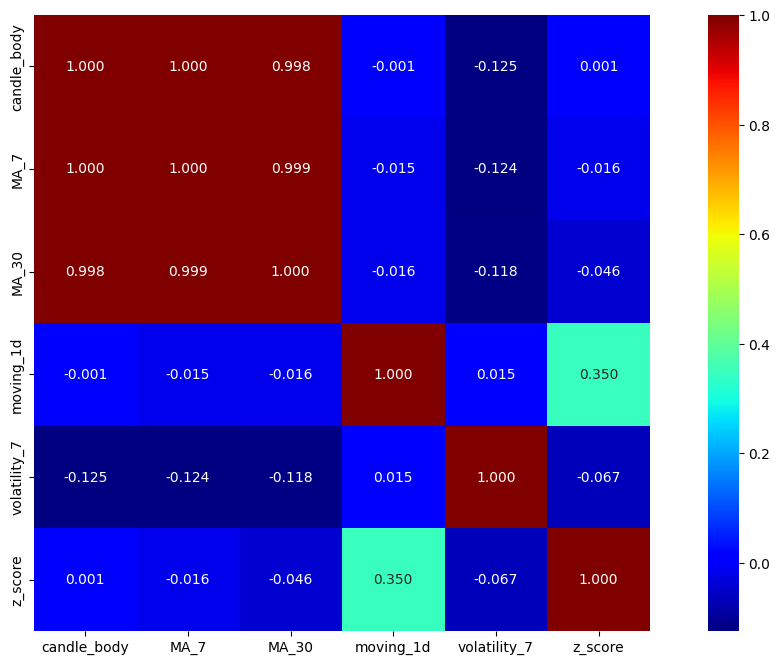

In [70]:
plt.figure(figsize=(15,8))
corr8=df1[['candle_body','MA_7','MA_30','moving_1d','volatility_7','z_score']].corr()
sns.heatmap(corr8,annot=True,square=True,cmap='jet',fmt='0.3f')
plt.show()

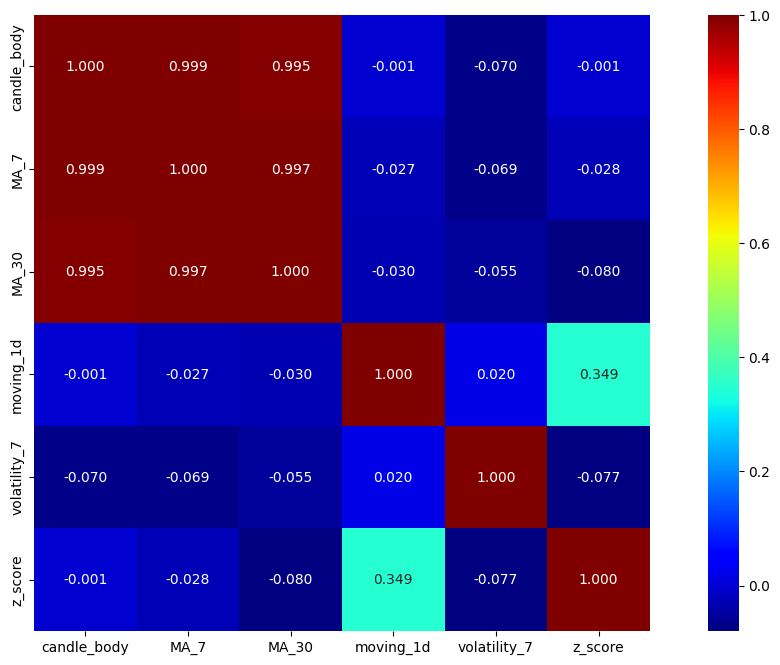

In [71]:

plt.figure(figsize=(15,8))
corr9=df2[['candle_body','MA_7','MA_30','moving_1d','volatility_7','z_score']].corr()
sns.heatmap(corr9,annot=True,square=True,cmap='jet',fmt='0.3f')
plt.show()

In [72]:
combined=pd.concat([df1,df2],ignore_index=True)
combined.to_csv("eth_btc_data.csv",index=False)

In [73]:
df3=pd.read_csv("eth_btc_data.csv")

In [74]:
df3.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-05 20:00:00,7444.71,7445.00,7318.00,7358.75,6550.969538,4.830521e+07,56284,2918.176154,2.152234e+07,...,2.475285,0.445457,0.320866,0.003261,0.554543,0.0,4.0,0.634257,0.884746,Bigup
1,2020-01-06 00:00:00,7357.64,7580.00,7346.76,7540.90,13578.258656,1.016581e+08,90571,7253.706938,5.428938e+07,...,-0.437481,0.534215,0.832362,0.025399,0.465785,0.0,4.0,0.909539,1.899092,Bigdown
2,2020-01-06 04:00:00,7540.90,7554.61,7496.00,7507.91,4822.718155,3.628604e+07,44909,2533.851605,1.906445e+07,...,0.490283,0.525399,0.203208,0.004270,0.474601,0.0,5.0,0.924428,1.919602,Bigup
3,2020-01-06 08:00:00,7508.18,7582.27,7507.39,7544.72,7827.327593,5.904338e+07,71448,3633.641591,2.741197e+07,...,-0.327779,0.464225,0.498531,0.010865,0.535775,0.0,4.0,0.923365,1.488018,Stable
4,2020-01-06 12:00:00,7544.72,7622.00,7465.44,7519.99,9210.893924,6.948383e+07,74063,4670.265212,3.524162e+07,...,0.264761,0.507037,0.348429,0.013158,0.492963,0.0,4.0,0.934383,0.506953,Stable


In [75]:
cols_to_drop = [
    'open',
    'high',
    'low',
    'close',
    'volume',
    'quote_volume',
    'taker_buy_quote',
    'next_close',
    'next_return',
    'MA_7','MA_30'
]



In [76]:
df1 = df1.drop(columns=cols_to_drop).reset_index(drop=True)
df2 = df2.drop(columns=cols_to_drop).reset_index(drop=True)
df3 = df3.drop(columns=cols_to_drop).reset_index(drop=True)

In [77]:
df1.head()

,date,num_trades,taker_buy_volume,type,candle_body,high_low_range,ma7_ratio,ma30_ratio,moving_1d,volatility_7,...,z_score,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-05 20:00:00,56284,2918.176154,BTC,7357.75,7444.005538,-0.009158,0.013047,-1.147077,0.907270,...,0.655265,0.445457,0.320866,0.003261,0.554543,0.0,4.0,0.634257,0.884746,Bigup
1,2020-01-06 00:00:00,90571,7253.706938,BTC,7539.90,7579.025745,0.011733,0.036620,2.475285,1.295897,...,1.741604,0.534215,0.832362,0.025399,0.465785,0.0,4.0,0.909539,1.899092,Bigdown
2,2020-01-06 04:00:00,44909,2533.851605,BTC,7506.91,7553.611586,0.006691,0.030677,-0.437481,1.185169,...,1.412528,0.525399,0.203208,0.004270,0.474601,0.0,5.0,0.924428,1.919602,Bigup
3,2020-01-06 08:00:00,71448,3633.641591,BTC,7543.72,7581.274948,0.010057,0.034086,0.490283,1.189660,...,1.514532,0.464225,0.498531,0.010865,0.535775,0.0,4.0,0.923365,1.488018,Stable
4,2020-01-06 12:00:00,74063,4670.265212,BTC,7518.99,7621.007254,0.004870,0.029353,-0.327779,1.169993,...,1.270947,0.507037,0.348429,0.013158,0.492963,0.0,4.0,0.934383,0.506953,Stable


In [78]:
df1.columns.tolist()

['date',
 'num_trades',
 'taker_buy_volume',
 'type',
 'candle_body',
 'high_low_range',
 'ma7_ratio',
 'ma30_ratio',
 'moving_1d',
 'volatility_7',
 'volumespike',
 'z_score',
 'taker_buy_ratio',
 'price_position',
 'momentum_7',
 'taker_sell_ratio',
 'negative_momentum',
 'down_days_7',
 'volatility_14',
 'volatility_3',
 'label']

In [79]:

df2.shape

(13877, 21)

In [80]:
df1.head()

,date,num_trades,taker_buy_volume,type,candle_body,high_low_range,ma7_ratio,ma30_ratio,moving_1d,volatility_7,...,z_score,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-05 20:00:00,56284,2918.176154,BTC,7357.75,7444.005538,-0.009158,0.013047,-1.147077,0.907270,...,0.655265,0.445457,0.320866,0.003261,0.554543,0.0,4.0,0.634257,0.884746,Bigup
1,2020-01-06 00:00:00,90571,7253.706938,BTC,7539.90,7579.025745,0.011733,0.036620,2.475285,1.295897,...,1.741604,0.534215,0.832362,0.025399,0.465785,0.0,4.0,0.909539,1.899092,Bigdown
2,2020-01-06 04:00:00,44909,2533.851605,BTC,7506.91,7553.611586,0.006691,0.030677,-0.437481,1.185169,...,1.412528,0.525399,0.203208,0.004270,0.474601,0.0,5.0,0.924428,1.919602,Bigup
3,2020-01-06 08:00:00,71448,3633.641591,BTC,7543.72,7581.274948,0.010057,0.034086,0.490283,1.189660,...,1.514532,0.464225,0.498531,0.010865,0.535775,0.0,4.0,0.923365,1.488018,Stable
4,2020-01-06 12:00:00,74063,4670.265212,BTC,7518.99,7621.007254,0.004870,0.029353,-0.327779,1.169993,...,1.270947,0.507037,0.348429,0.013158,0.492963,0.0,4.0,0.934383,0.506953,Stable


In [81]:
df3.shape

(27754, 21)

In [82]:
df3.columns.tolist()

['date',
 'num_trades',
 'taker_buy_volume',
 'type',
 'candle_body',
 'high_low_range',
 'ma7_ratio',
 'ma30_ratio',
 'moving_1d',
 'volatility_7',
 'volumespike',
 'z_score',
 'taker_buy_ratio',
 'price_position',
 'momentum_7',
 'taker_sell_ratio',
 'negative_momentum',
 'down_days_7',
 'volatility_14',
 'volatility_3',
 'label']

In [83]:
df3.shape

(27754, 21)

# **BNB_SOL**

In [85]:
df4 = pd.read_csv('all_data/bnb_4h_binance.csv')
df4.head(3)

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote
0,2020-01-01 00:00:00,13.7159,13.8500,13.6903,13.8170,227004.40,3.127030e+06,5109,149035.30,2.053238e+06
1,2020-01-01 04:00:00,13.8157,13.8501,13.7428,13.7608,132921.02,1.834921e+06,3455,89936.94,1.241678e+06
2,2020-01-01 08:00:00,13.7618,13.8125,13.6813,13.7190,171250.42,2.352581e+06,5788,117620.64,1.615786e+06


In [88]:
df5 = pd.read_csv('all_data/sol_4h_binance.csv')
df5.head(3)

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote
0,2020-08-11 04:00:00,2.8500,3.4700,2.8500,2.9224,62101.63,1.865991e+05,739,23866.78,7.200030e+04
1,2020-08-11 08:00:00,2.9626,3.1000,2.8433,3.0497,89812.46,2.627430e+05,874,32831.25,9.659731e+04
2,2020-08-11 12:00:00,3.0497,3.5208,2.8625,3.1900,902874.94,2.900385e+06,7159,443787.22,1.425806e+06


In [89]:
df4['type'] = 'BNB'
df5['type'] = 'SOL'

In [90]:
df4.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,type
0,2020-01-01 00:00:00,13.7159,13.8500,13.6903,13.8170,227004.40,3.127030e+06,5109,149035.30,2.053238e+06,BNB
1,2020-01-01 04:00:00,13.8157,13.8501,13.7428,13.7608,132921.02,1.834921e+06,3455,89936.94,1.241678e+06,BNB
2,2020-01-01 08:00:00,13.7618,13.8125,13.6813,13.7190,171250.42,2.352581e+06,5788,117620.64,1.615786e+06,BNB
3,2020-01-01 12:00:00,13.7190,13.8692,13.7168,13.8223,150269.00,2.074335e+06,4583,87371.69,1.205913e+06,BNB
4,2020-01-01 16:00:00,13.8223,13.8671,13.6715,13.7229,150101.29,2.066388e+06,4808,72801.94,1.002524e+06,BNB


In [91]:
df5[30:40]

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,type
30,2020-08-16 04:00:00,3.1920,3.4907,3.1697,3.4401,195490.30,656289.671170,3417,88201.03,297346.422605,SOL
31,2020-08-16 08:00:00,3.4401,3.4700,3.3400,3.4193,112899.67,383003.895320,1844,33839.25,114980.190463,SOL
32,2020-08-16 12:00:00,3.4193,3.4427,3.3400,3.3872,89743.61,303104.293882,1306,48835.63,165063.863600,SOL
33,2020-08-16 16:00:00,3.3911,3.4726,3.3790,3.4071,65724.85,226142.850897,1099,28436.43,97960.676634,SOL
34,2020-08-16 20:00:00,3.4115,3.4426,3.3600,3.3885,34541.27,117272.469853,717,17975.62,61025.431140,SOL
35,2020-08-17 00:00:00,3.3885,3.3952,3.3235,3.3502,87476.01,293747.168659,915,24255.69,81543.889814,SOL
36,2020-08-17 04:00:00,3.3551,3.3666,3.2000,3.2001,173481.74,567973.145992,1992,55807.45,182895.408735,SOL
37,2020-08-17 08:00:00,3.2034,3.3234,3.2002,3.2891,100401.83,329035.658848,1195,42611.67,139862.725561,SOL
38,2020-08-17 12:00:00,3.2891,3.2934,3.1000,3.1264,174288.90,553232.558081,2287,48568.08,154691.622372,SOL
39,2020-08-17 16:00:00,3.1347,3.2150,3.1100,3.1541,135874.82,428651.540289,1532,65515.47,206768.750461,SOL


In [92]:
df4.isna().sum()

date                0
open                0
high                0
low                 0
close               0
volume              0
quote_volume        0
num_trades          0
taker_buy_volume    0
taker_buy_quote     0
type                0
dtype: int64

In [93]:
df5.isna().sum()

date                0
open                0
high                0
low                 0
close               0
volume              0
quote_volume        0
num_trades          0
taker_buy_volume    0
taker_buy_quote     0
type                0
dtype: int64

In [94]:

df4.duplicated().sum()

np.int64(0)

In [95]:
df5.duplicated().sum()

np.int64(0)

In [96]:
df4['date']=pd.to_datetime(df4['date'])
df4['year']=df4['date'].dt.year
df4['year'].value_counts()

year
2024    2196
2020    2195
2021    2190
2022    2190
2023    2190
2025    2190
2026     756
Name: count, dtype: int64

In [97]:
df5['date']=pd.to_datetime(df5['date'])
df5['year']=df5['date'].dt.year
df5['year'].value_counts()

year
2024    2196
2022    2190
2021    2190
2025    2190
2023    2190
2020     857
2026     756
Name: count, dtype: int64

In [98]:
df4.drop(columns='year',inplace=True)
df5.drop(columns='year',inplace=True)

In [99]:
df4.duplicated().sum()

np.int64(0)

In [100]:
df5.duplicated().sum()

np.int64(0)

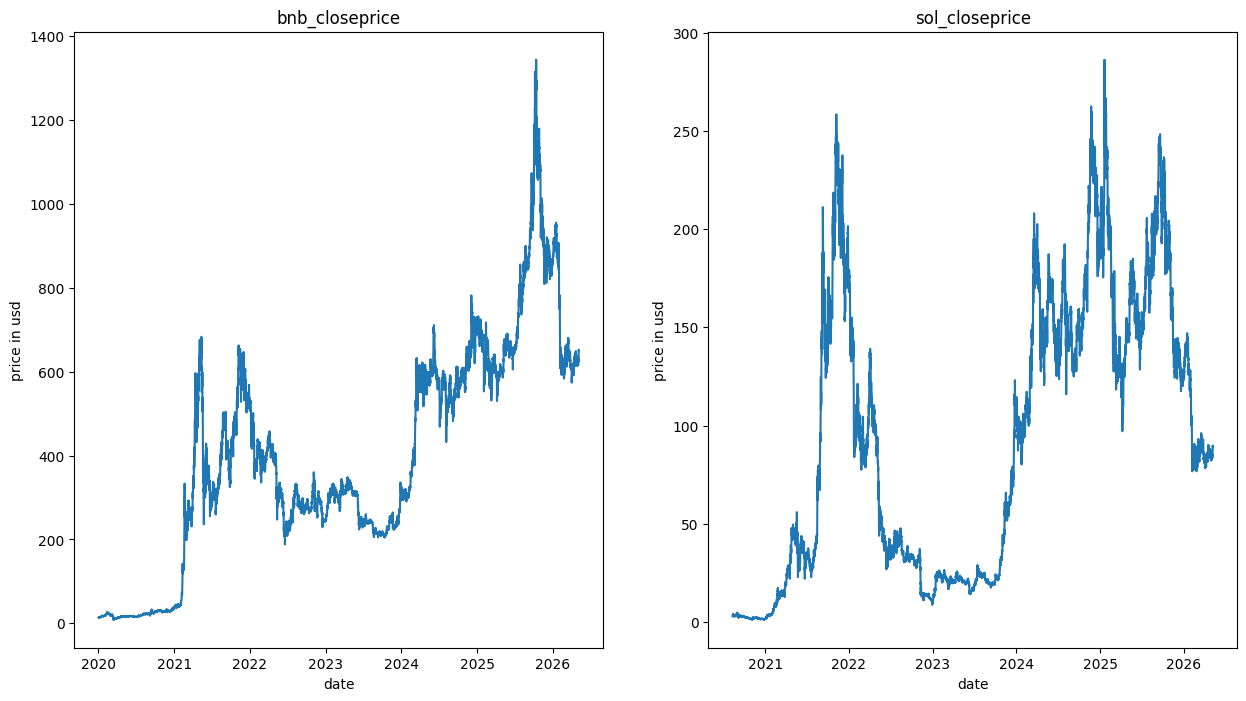

In [101]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
sns.lineplot(x='date',data=df4,y='close')
plt.title("bnb_closeprice")
plt.ylabel("price in usd")
plt.subplot(1,2,2)
sns.lineplot(x='date',data=df5,y='close')
plt.title("sol_closeprice")
plt.ylabel("price in usd")
plt.show()

C:\Users\ibrah\AppData\Local\Temp\ipykernel_28696\2521454798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year',data=df4,y='close', palette = 'viridis')
C:\Users\ibrah\AppData\Local\Temp\ipykernel_28696\2521454798.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year',data=df5,y='close', palette = 'magma')


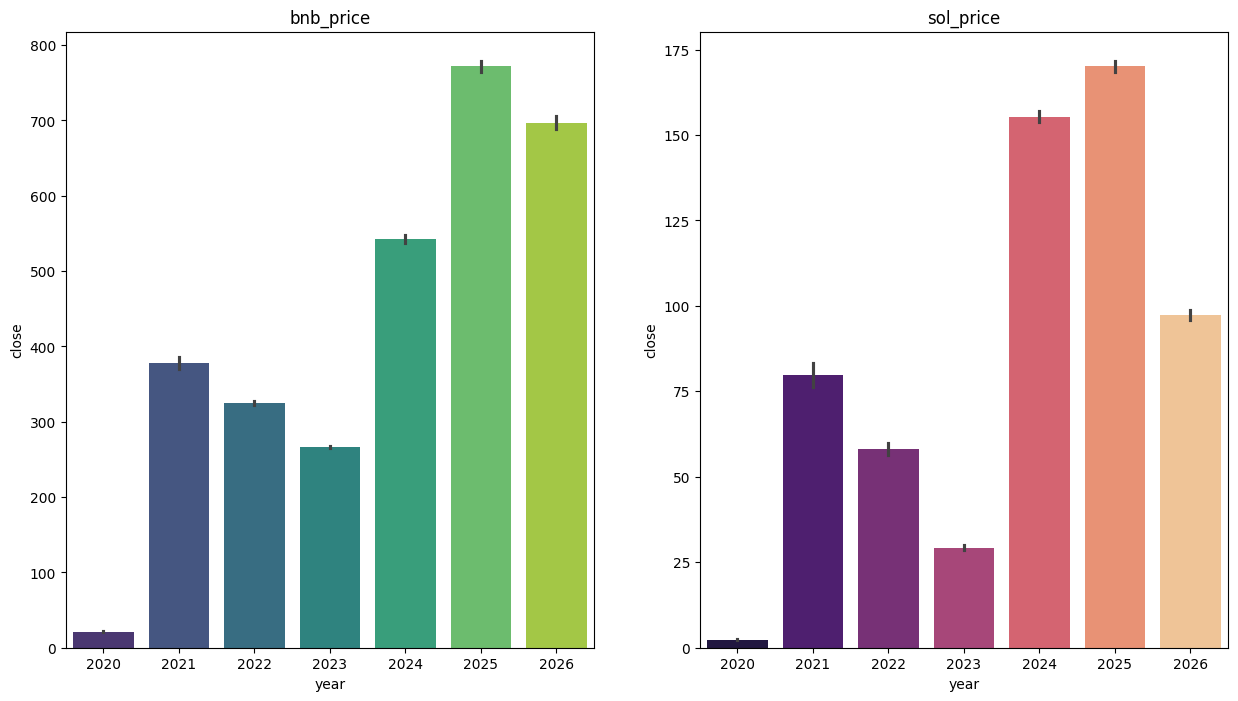

In [102]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
df4['year']=df4['date'].dt.year
sns.barplot(x='year',data=df4,y='close', palette = 'viridis')
plt.title("bnb_price")
plt.subplot(1,2,2)
df5['year']=df5['date'].dt.year
sns.barplot(x='year',data=df5,y='close', palette = 'magma')
plt.title("sol_price")
plt.show()

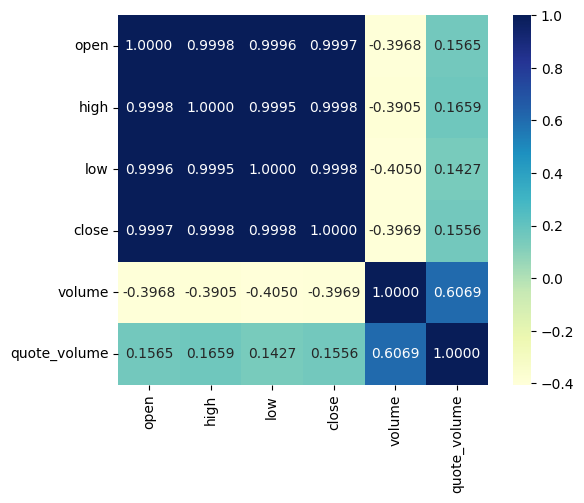

In [103]:
corr4=df4[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr4,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

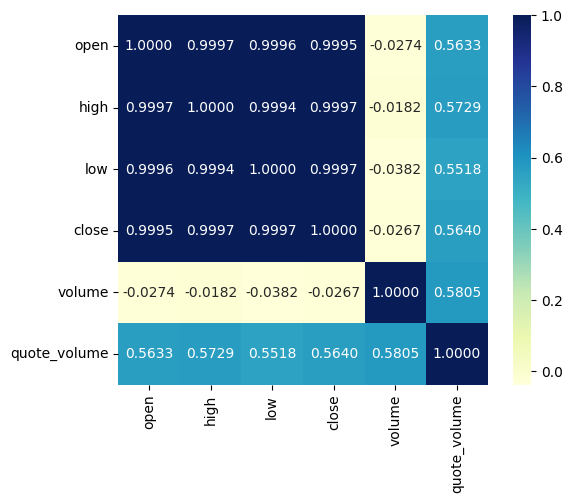

In [104]:
corr5=df5[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr5,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

In [105]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025]:
    bnb_year = df4[df4['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x = bnb_year['date'],
        open = bnb_year['open'],
        high = bnb_year['high'],
        low = bnb_year['low'],
        close = bnb_year['close']
    )])

    fig.update_layout(title=f'BNB Candlestick Chart - {year}')
    fig.show()"""

"for year in [2020, 2021, 2022, 2023, 2024,2025]:\n    bnb_year = df4[df4['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x = bnb_year['date'],\n        open = bnb_year['open'],\n        high = bnb_year['high'],\n        low = bnb_year['low'],\n        close = bnb_year['close']\n    )])\n\n    fig.update_layout(title=f'BNB Candlestick Chart - {year}')\n    fig.show()"

In [106]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025]:
    sol_year = df5[df5['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x = sol_year['date'],
        open = sol_year['open'],
        high = sol_year['high'],
        low = sol_year['low'],
        close = sol_year['close']
    )])

    fig.update_layout(title=f'SOL Candlestick Chart - {year}')
    fig.show()"""

"for year in [2020, 2021, 2022, 2023, 2024,2025]:\n    sol_year = df5[df5['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x = sol_year['date'],\n        open = sol_year['open'],\n        high = sol_year['high'],\n        low = sol_year['low'],\n        close = sol_year['close']\n    )])\n\n    fig.update_layout(title=f'SOL Candlestick Chart - {year}')\n    fig.show()"

In [107]:
df4['candle_body']=df4['close']-df4['open']/df4['open']
df5['candle_body']=df5['close']-df5['open']/df5['open']

df4['high_low_range']=df4['high']-df4['low']/ df4['close']
df5['high_low_range']=df5['high']-df5['low'] / df5['close']

In [108]:
df4['MA_7']=df4['close'].rolling(window=7).mean()
df5['MA_7']=df5['close'].rolling(window=7).mean()

df4['MA_30']=df4['close'].rolling(window=30).mean()
df5['MA_30']=df5['close'].rolling(window=30).mean()

In [109]:
df4['ma7_ratio'] = df4['close'] / df4['MA_7'] - 1
df4['ma30_ratio'] = df4['close'] / df4['MA_30'] - 1

df5['ma7_ratio'] = df5['close'] / df5['MA_7'] - 1
df5['ma30_ratio'] = df5['close'] / df5['MA_30'] - 1

In [110]:
df4['moving_1d'] = df4['close'].pct_change() * 100
df5['moving_1d'] = df5['close'].pct_change() * 100


In [111]:
df4["volatility_7"] = df4["moving_1d"].rolling(window=7).std()
df5["volatility_7"] = df5["moving_1d"].rolling(window=7).std()

In [112]:
df4["volume_MA7"] = df4["volume"].rolling(window=7).mean()
df4["volumespike"] = df4["volume"] / df4["volume_MA7"]
df5["volume_MA7"] = df5["volume"].rolling(window=7).mean()
df5["volumespike"] = df5["volume"] / df5["volume_MA7"]

In [113]:
df4["rolling_mean_30"] = df4["close"].rolling(window=30).mean()
df4["rolling_std_30"]  = df4["close"].rolling(window=30).std()
df4["z_score"] = (df4["close"] - df4["rolling_mean_30"]) / df4["rolling_std_30"]

In [114]:
df5["rolling_mean_30"] = df5["close"].rolling(window=30).mean()
df5["rolling_std_30"]  = df5["close"].rolling(window=30).std()
df5["z_score"] = (df5["close"] - df5["rolling_mean_30"]) / df5["rolling_std_30"]

In [115]:
df4.drop(columns='volume_MA7',inplace=True)
df4.drop(columns='rolling_mean_30',inplace=True)
df4.drop(columns='rolling_std_30',inplace=True)
df5.drop(columns='volume_MA7',inplace=True)
df5.drop(columns='rolling_mean_30',inplace=True)
df5.drop(columns='rolling_std_30',inplace=True)

In [116]:
df4['next_close'] = df4['close'].shift(-1)
df4['next_return'] = (df4['next_close'] - df4['close']) / df4['close'] * 100

df4.head(3)

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,MA_7,MA_30,ma7_ratio,ma30_ratio,moving_1d,volatility_7,volumespike,z_score,next_close,next_return
0,2020-01-01 00:00:00,13.7159,13.8500,13.6903,13.8170,227004.40,3.127030e+06,5109,149035.30,2.053238e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.7608,-0.406745
1,2020-01-01 04:00:00,13.8157,13.8501,13.7428,13.7608,132921.02,1.834921e+06,3455,89936.94,1.241678e+06,...,NaN,NaN,NaN,NaN,-0.406745,NaN,NaN,NaN,13.7190,-0.303761
2,2020-01-01 08:00:00,13.7618,13.8125,13.6813,13.7190,171250.42,2.352581e+06,5788,117620.64,1.615786e+06,...,NaN,NaN,NaN,NaN,-0.303761,NaN,NaN,NaN,13.8223,0.752970


In [117]:
df5['next_close'] = df5['close'].shift(-1)
df5['next_return'] = (df5['next_close'] - df5['close']) / df5['close'] * 100

df5.head(3)

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,MA_7,MA_30,ma7_ratio,ma30_ratio,moving_1d,volatility_7,volumespike,z_score,next_close,next_return
0,2020-08-11 04:00:00,2.8500,3.4700,2.8500,2.9224,62101.63,1.865991e+05,739,23866.78,7.200030e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0497,4.356009
1,2020-08-11 08:00:00,2.9626,3.1000,2.8433,3.0497,89812.46,2.627430e+05,874,32831.25,9.659731e+04,...,NaN,NaN,NaN,NaN,4.356009,NaN,NaN,NaN,3.1900,4.600453
2,2020-08-11 12:00:00,3.0497,3.5208,2.8625,3.1900,902874.94,2.900385e+06,7159,443787.22,1.425806e+06,...,NaN,NaN,NaN,NaN,4.600453,NaN,NaN,NaN,3.1886,-0.043887


In [118]:
df4['taker_buy_ratio'] = df4['taker_buy_volume'] / df4['volume']
df4['price_position']  = (df4['close'] - df4['low']) / (df4['high'] - df4['low'])
df4['momentum_7']      = df4['close'] / df4['close'].shift(7) - 1

df5['taker_buy_ratio'] = df5['taker_buy_volume'] / df5['volume']
df5['price_position']  = (df5['close'] - df5['low']) / (df5['high'] - df5['low'])
df5['momentum_7']      = df5['close'] / df5['close'].shift(7) - 1

In [119]:
df4['taker_sell_ratio']  = 1 - df4['taker_buy_ratio']  # bearish pressure
df4['negative_momentum'] = df4['momentum_7'].apply(lambda x: x if x < 0 else 0)
df4['down_days_7']       = (df4['moving_1d'] < 0).rolling(7).sum()  # count down days

df5['taker_sell_ratio']  = 1 - df5['taker_buy_ratio']  # bearish pressure
df5['negative_momentum'] = df5['momentum_7'].apply(lambda x: x if x < 0 else 0)
df5['down_days_7']       = (df5['moving_1d'] < 0).rolling(7).sum()  # count down days

In [120]:
df4['volatility_14'] = df4['moving_1d'].rolling(14).std()
df4['volatility_3']  = df4['moving_1d'].rolling(3).std()

df5['volatility_14'] = df5['moving_1d'].rolling(14).std()
df5['volatility_3']  = df5['moving_1d'].rolling(3).std()

In [121]:
q_low = df4['next_return'].quantile(0.30)
q_high = df4['next_return'].quantile(0.70)
df4['label'] = df4['next_return'].apply(lambda x: 'Bigup' if x > q_high else ('Bigdown' if x < q_low else 'Stable'))

q_low = df5['next_return'].quantile(0.30)
q_high = df5['next_return'].quantile(0.70)
df5['label'] = df5['next_return'].apply(lambda x: 'Bigup' if x > q_high else ('Bigdown' if x < q_low else 'Stable'))

In [122]:
df4.drop("year",axis=1,inplace=True)
df5.drop("year",axis=1,inplace=True)


In [123]:
print(df4.isna().sum())
print("-"*50)
print(df5.isna().sum())

date                  0
open                  0
high                  0
low                   0
close                 0
volume                0
quote_volume          0
num_trades            0
taker_buy_volume      0
taker_buy_quote       0
type                  0
candle_body           0
high_low_range        0
MA_7                  6
MA_30                29
ma7_ratio             6
ma30_ratio           29
moving_1d             1
volatility_7          7
volumespike           6
z_score              29
next_close            1
next_return           1
taker_buy_ratio       0
price_position        0
momentum_7            7
taker_sell_ratio      0
negative_momentum     0
down_days_7           6
volatility_14        14
volatility_3          3
label                 0
dtype: int64
--------------------------------------------------
date                  0
open                  0
high                  0
low                   0
close                 0
volume                0
quote_volume          0


In [124]:
df4.dropna(inplace=True)
df5.dropna(inplace=True)
df4.reset_index(drop=True,inplace=True)
df5.reset_index(drop=True,inplace=True)

In [125]:
df4 = df4.drop(columns=cols_to_drop).reset_index(drop=True)
df5 = df5.drop(columns=cols_to_drop).reset_index(drop=True)

In [126]:
df4.head()

,date,num_trades,taker_buy_volume,type,candle_body,high_low_range,ma7_ratio,ma30_ratio,moving_1d,volatility_7,...,z_score,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-05 20:00:00,5847,109895.52,BNB,13.0532,13.245225,-0.000850,0.026354,-1.212594,1.141558,...,1.205922,0.545639,0.490791,0.023085,0.454361,0.0,3.0,0.812625,1.551601,Bigup
1,2020-01-06 00:00:00,10425,228348.09,BNB,13.3995,13.462777,0.017669,0.050156,2.464207,1.401867,...,2.113780,0.544584,0.912494,0.042747,0.455416,0.0,3.0,1.008058,1.892880,Stable
2,2020-01-06 04:00:00,5653,93592.11,BNB,13.3690,13.441200,0.012050,0.046385,-0.211813,1.354846,...,1.836877,0.467562,0.587052,0.024163,0.532438,0.0,4.0,1.016238,1.900944,Bigup
3,2020-01-06 08:00:00,12385,166608.92,BNB,13.6995,13.799096,0.029122,0.067911,2.300090,1.545590,...,2.402331,0.537003,0.816106,0.042503,0.462997,0.0,4.0,1.135779,1.499871,Bigdown
4,2020-01-06 12:00:00,9988,123791.91,BNB,13.5121,13.820369,0.010725,0.052538,-1.274873,1.628460,...,1.756845,0.509123,0.003234,0.037320,0.490877,0.0,4.0,1.234000,1.835762,Bigup


In [127]:
df5.head()

,date,num_trades,taker_buy_volume,type,candle_body,high_low_range,ma7_ratio,ma30_ratio,moving_1d,volatility_7,...,z_score,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-08-16 00:00:00,2276,50151.52,SOL,2.1955,2.283827,-0.046920,-0.087112,0.709108,3.555228,...,-1.107054,0.295519,0.538516,-0.062876,0.704481,-0.062876,5.0,3.387274,3.278725,Bigup
1,2020-08-16 04:00:00,3417,88201.03,SOL,2.4401,2.569302,0.021195,-0.022056,7.654514,4.687894,...,-0.306294,0.451179,0.842368,0.033404,0.548821,0.000000,4.0,4.080455,6.728918,Stable
2,2020-08-16 08:00:00,1844,33839.25,SOL,2.4193,2.493192,0.019439,-0.031362,-0.604634,4.084834,...,-0.464558,0.299729,0.610000,-0.029022,0.700271,-0.029022,5.0,4.026389,4.438057,Bigdown
3,2020-08-16 12:00:00,1306,48835.63,SOL,2.3872,2.456635,0.012577,-0.042239,-0.938789,4.030448,...,-0.646058,0.544168,0.459591,-0.018203,0.455832,-0.018203,5.0,4.000346,4.867752,Stable
4,2020-08-16 16:00:00,1099,28436.43,SOL,2.4071,2.480847,0.019628,-0.038592,0.587506,4.037428,...,-0.612793,0.432659,0.300214,-0.007371,0.567341,-0.007371,4.0,3.749881,0.802333,Stable


In [128]:
df4.shape

(13877, 21)

## XRP and AVAX(cordano)

In [158]:
df6=pd.read_csv("all_data/xrp_4h_binance.csv")
df7=pd.read_csv("all_data/avax_4h_binance.csv")

In [159]:
df7.shape

(12317, 10)

In [160]:
df6.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote
0,2020-01-01 00:00:00,0.19285,0.19454,0.19219,0.19397,6926988.2,1.340087e+06,6102,3966612.9,767756.389715
1,2020-01-01 04:00:00,0.19397,0.19526,0.19351,0.19438,4159719.0,8.083955e+05,4725,2329652.4,452672.428572
2,2020-01-01 08:00:00,0.19438,0.19468,0.19326,0.19358,5420125.1,1.051844e+06,5029,3103466.8,602360.267600
3,2020-01-01 12:00:00,0.19358,0.19488,0.19350,0.19394,4114708.1,7.987685e+05,4633,2148929.5,417174.324268
4,2020-01-01 16:00:00,0.19394,0.19483,0.19380,0.19395,3358625.4,6.525124e+05,4597,1955487.2,379889.046839


In [161]:
df7.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote
0,2020-09-22 04:00:00,0.8500,6.0000,0.8500,4.9096,6369386.27,3.058682e+07,65567,3281877.77,1.583425e+07
1,2020-09-22 08:00:00,4.9096,7.0000,4.8200,5.7679,12206384.53,7.256299e+07,143010,6401175.54,3.802951e+07
2,2020-09-22 12:00:00,5.7679,6.1500,4.3110,4.6699,6012583.05,3.136951e+07,84276,2803116.05,1.462521e+07
3,2020-09-22 16:00:00,4.6691,4.8902,4.0266,4.4800,3739983.85,1.681733e+07,46355,1818393.01,8.189857e+06
4,2020-09-22 20:00:00,4.4854,5.5499,4.2354,5.3193,3113545.46,1.537866e+07,36676,1563246.33,7.712972e+06


In [162]:
df6.isna().sum()

date                0
open                0
high                0
low                 0
close               0
volume              0
quote_volume        0
num_trades          0
taker_buy_volume    0
taker_buy_quote     0
dtype: int64

In [163]:
df7.isna().sum()

date                0
open                0
high                0
low                 0
close               0
volume              0
quote_volume        0
num_trades          0
taker_buy_volume    0
taker_buy_quote     0
dtype: int64

In [164]:
df6["date"]=pd.to_datetime(df6['date'])
df6["year"]=df6['date'].dt.year
df6['year'].value_counts()

year
2024    2196
2020    2195
2021    2190
2022    2190
2023    2190
2025    2190
2026     756
Name: count, dtype: int64

In [165]:
df6=df6.drop(columns="year")
df6.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'quote_volume',
       'num_trades', 'taker_buy_volume', 'taker_buy_quote'],
      dtype='object')

In [166]:
df7["type"]='ADA'
df7.head(10)

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,type
0,2020-09-22 04:00:00,0.8500,6.0000,0.8500,4.9096,6369386.27,3.058682e+07,65567,3281877.77,1.583425e+07,ADA
1,2020-09-22 08:00:00,4.9096,7.0000,4.8200,5.7679,12206384.53,7.256299e+07,143010,6401175.54,3.802951e+07,ADA
2,2020-09-22 12:00:00,5.7679,6.1500,4.3110,4.6699,6012583.05,3.136951e+07,84276,2803116.05,1.462521e+07,ADA
3,2020-09-22 16:00:00,4.6691,4.8902,4.0266,4.4800,3739983.85,1.681733e+07,46355,1818393.01,8.189857e+06,ADA
4,2020-09-22 20:00:00,4.4854,5.5499,4.2354,5.3193,3113545.46,1.537866e+07,36676,1563246.33,7.712972e+06,ADA
5,2020-09-23 00:00:00,5.3279,5.3600,4.6000,4.9135,1558881.51,7.664214e+06,22006,723758.62,3.570424e+06,ADA
6,2020-09-23 04:00:00,4.9135,4.9455,3.9169,4.1197,2730293.14,1.180209e+07,38590,1222200.34,5.283732e+06,ADA
7,2020-09-23 08:00:00,4.1184,4.4000,4.0295,4.2108,1779716.39,7.508313e+06,29382,889665.43,3.756059e+06,ADA
8,2020-09-23 12:00:00,4.2108,4.6172,4.0191,4.1073,2598338.02,1.110400e+07,31271,1274689.06,5.454581e+06,ADA
9,2020-09-23 16:00:00,4.0996,4.3300,3.6500,3.7238,2106852.31,8.452019e+06,23633,938347.48,3.779337e+06,ADA


In [167]:
df6["type"]='XRP'
df6.head(10)

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,type
0,2020-01-01 00:00:00,0.19285,0.19454,0.19219,0.19397,6926988.2,1.340087e+06,6102,3966612.9,767756.389715,XRP
1,2020-01-01 04:00:00,0.19397,0.19526,0.19351,0.19438,4159719.0,8.083955e+05,4725,2329652.4,452672.428572,XRP
2,2020-01-01 08:00:00,0.19438,0.19468,0.19326,0.19358,5420125.1,1.051844e+06,5029,3103466.8,602360.267600,XRP
3,2020-01-01 12:00:00,0.19358,0.19488,0.19350,0.19394,4114708.1,7.987685e+05,4633,2148929.5,417174.324268,XRP
4,2020-01-01 16:00:00,0.19394,0.19483,0.19380,0.19395,3358625.4,6.525124e+05,4597,1955487.2,379889.046839,XRP
5,2020-01-01 20:00:00,0.19392,0.19422,0.19226,0.19305,5792856.8,1.119826e+06,5197,2288448.0,442249.418418,XRP
6,2020-01-02 00:00:00,0.19304,0.19304,0.19045,0.19093,4948417.8,9.499937e+05,4899,2427894.3,466193.026713,XRP
7,2020-01-02 04:00:00,0.19089,0.19163,0.19041,0.19081,5137702.2,9.815783e+05,5090,2359804.7,450839.850080,XRP
8,2020-01-02 08:00:00,0.19080,0.19230,0.19064,0.19142,4450974.5,8.533256e+05,4753,2156042.6,413368.799288,XRP
9,2020-01-02 12:00:00,0.19135,0.19173,0.19015,0.19054,5701474.3,1.088288e+06,5268,2639793.7,503965.316575,XRP


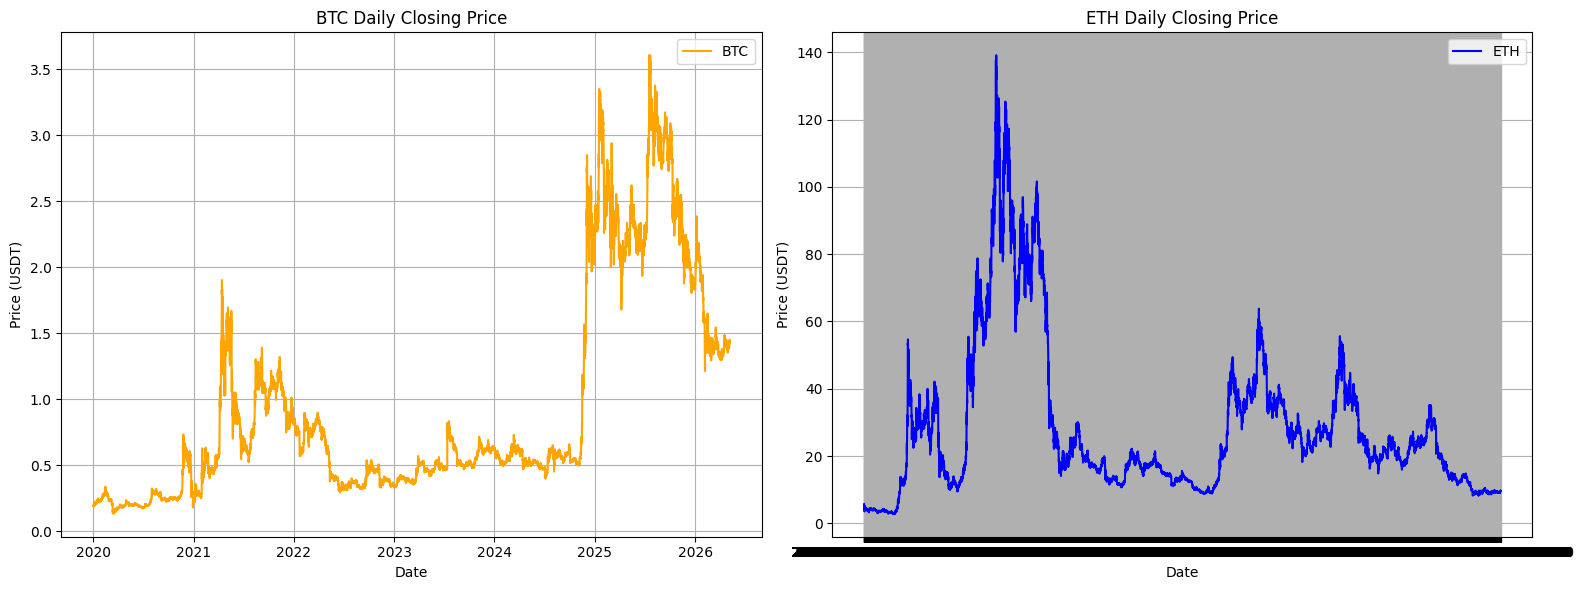

In [168]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(df6['date'], df6['close'], label='BTC', color='orange')
plt.title("BTC Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USDT)")
plt.legend()
plt.grid(True)
plt.subplot(1,2,2)
sns.lineplot(x=df7['date'], y=df7['close'], label='ETH', color='blue')
plt.title("ETH Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USDT)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

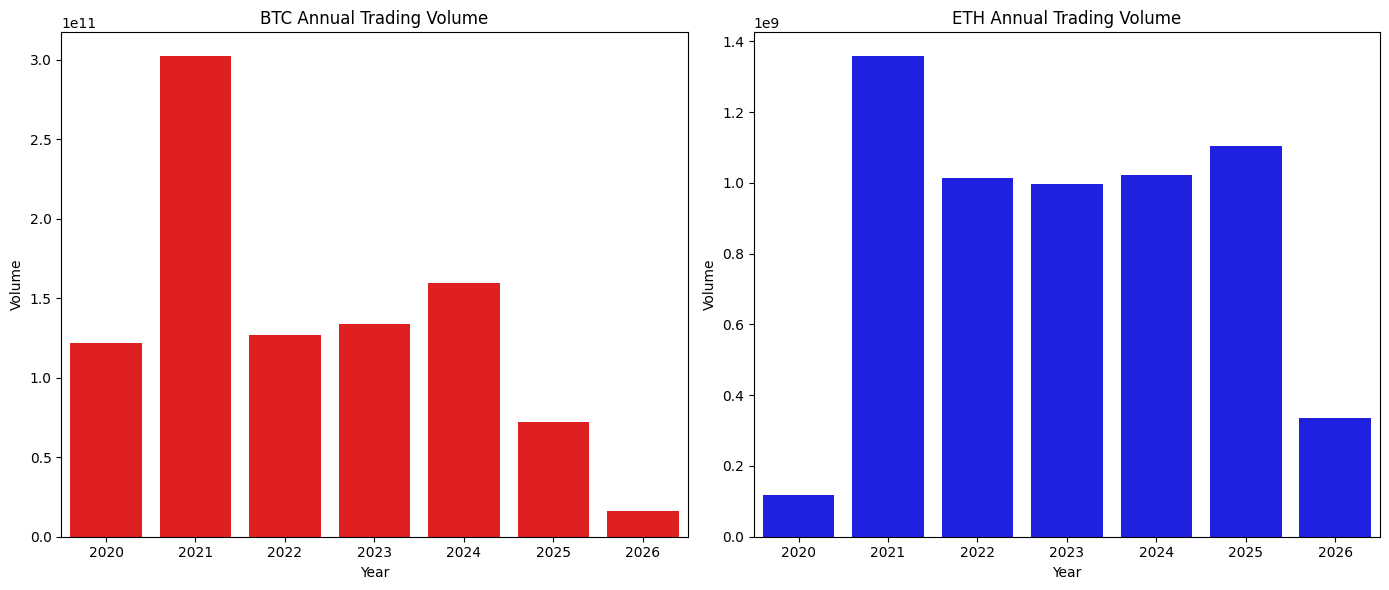

In [169]:

df6['date'] = pd.to_datetime(df6['date'], errors='coerce')
df7['date'] = pd.to_datetime(df7['date'], errors='coerce')
df6 = df6.dropna(subset=['date'])
df7 = df7.dropna(subset=['date'])
df6['year'] = df6['date'].dt.year
df7['year'] = df7['date'].dt.year
btc_yearly = df6.groupby('year')['volume'].sum().reset_index()
eth_yearly = df7.groupby('year')['volume'].sum().reset_index()
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.barplot(x='year', y='volume', data=btc_yearly, color='red')
plt.title("BTC Annual Trading Volume")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.subplot(1,2,2)
sns.barplot(x='year', y='volume', data=eth_yearly, color='blue')
plt.title("ETH Annual Trading Volume")
plt.xlabel("Year")
plt.ylabel("Volume")

plt.tight_layout()
plt.show()

In [170]:
df6[['open','high','low','close','volume','quote_volume']].describe()

,open,high,low,close,volume,quote_volume
count,13907.000000,13907.000000,13907.000000,13907.000000,1.390700e+04,1.390700e+04
mean,0.931284,0.943891,0.917666,0.931375,6.705105e+07,5.605006e+07
std,0.799102,0.809274,0.788144,0.799086,9.474727e+07,9.370271e+07
min,0.132390,0.141290,0.101290,0.132380,1.144045e+05,1.193847e+05
25%,0.394500,0.399700,0.389850,0.394550,2.304203e+07,1.464914e+07
50%,0.574000,0.581950,0.565100,0.574000,4.298458e+07,2.958300e+07
75%,1.232700,1.258200,1.202350,1.233650,7.467213e+07,5.864737e+07
max,3.605400,3.660700,3.527000,3.605400,3.272164e+09,2.036396e+09


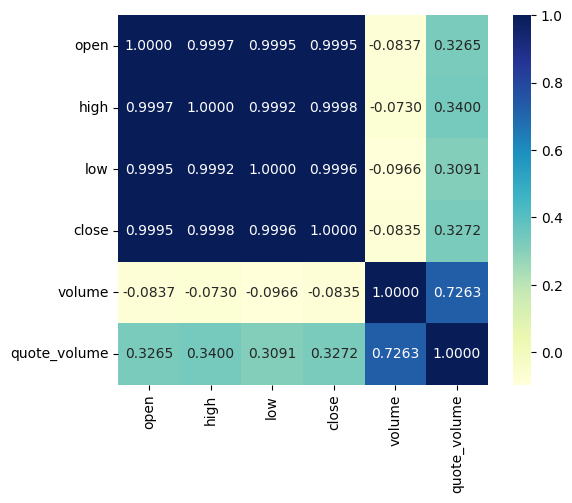

In [171]:

corr1 = df6[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr1, annot=True, square=True, fmt='.4f', cmap='YlGnBu')
plt.show()

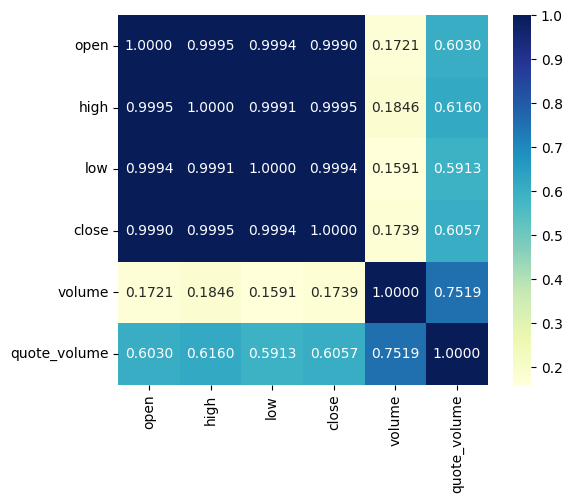

In [172]:

corr2=df7[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr2,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

In [173]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025,2026]:
    btc_year = df6[df6['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_year['date'],
        open=btc_year['open'],
        high=btc_year['high'],
        low=btc_year['low'],
        close=btc_year['close']
    )])

    fig.update_layout(title=f'BTC Candlestick Chart - {year}')
    fig.show()"""

"for year in [2020, 2021, 2022, 2023, 2024,2025,2026]:\n    btc_year = df6[df6['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=btc_year['date'],\n        open=btc_year['open'],\n        high=btc_year['high'],\n        low=btc_year['low'],\n        close=btc_year['close']\n    )])\n\n    fig.update_layout(title=f'BTC Candlestick Chart - {year}')\n    fig.show()"

In [174]:

"""years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
    2025: [1, 3, 12],
    2026: [2, 3, 11],
}
for year, months in years_months.items():
    btc_filtered = df6[(df6['date'].dt.year == year) & (df6['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_filtered['date'],
        open=btc_filtered['open'],
        high=btc_filtered['high'],
        low=btc_filtered['low'],
        close=btc_filtered['close']
    )])

    fig.update_layout(title=f'BTC Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()"""

"years_months = {\n    2020: [3, 8, 12],\n    2021: [1, 4, 11],\n    2022: [1, 5, 11],\n    2023: [1, 3, 10],\n    2024: [1, 3, 11],\n    2025: [1, 3, 12],\n    2026: [2, 3, 11],\n}\nfor year, months in years_months.items():\n    btc_filtered = df6[(df6['date'].dt.year == year) & (df6['date'].dt.month.isin(months))]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=btc_filtered['date'],\n        open=btc_filtered['open'],\n        high=btc_filtered['high'],\n        low=btc_filtered['low'],\n        close=btc_filtered['close']\n    )])\n\n    fig.update_layout(title=f'BTC Candlestick - {year} (Jan, Jun, Dec)')\n    fig.show()"

In [175]:

df7['date'] = pd.to_datetime(df7['date'])
df6['date'] = pd.to_datetime(df6['date'])

In [176]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025,2026]:
    btc_year = df7[df7['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_year['date'],
        open=btc_year['open'],
        high=btc_year['high'],
        low=btc_year['low'],
        close=btc_year['close']
    )])

    fig.update_layout(title=f'ETH Candlestick Chart - {year}')
    fig.show()"""


"for year in [2020, 2021, 2022, 2023, 2024,2025,2026]:\n    btc_year = df7[df7['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=btc_year['date'],\n        open=btc_year['open'],\n        high=btc_year['high'],\n        low=btc_year['low'],\n        close=btc_year['close']\n    )])\n\n    fig.update_layout(title=f'ETH Candlestick Chart - {year}')\n    fig.show()"

In [177]:
"""years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
    2025: [1, 3, 12],
    2026: [2, 3, 11],
}
for year, months in years_months.items():
    btc_filtered = df7[(df7['date'].dt.year == year) & (df7['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_filtered['date'],
        open=btc_filtered['open'],
        high=btc_filtered['high'],
        low=btc_filtered['low'],
        close=btc_filtered['close']
    )])

    fig.update_layout(title=f'ETH Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()"""

"years_months = {\n    2020: [3, 8, 12],\n    2021: [1, 4, 11],\n    2022: [1, 5, 11],\n    2023: [1, 3, 10],\n    2024: [1, 3, 11],\n    2025: [1, 3, 12],\n    2026: [2, 3, 11],\n}\nfor year, months in years_months.items():\n    btc_filtered = df7[(df7['date'].dt.year == year) & (df7['date'].dt.month.isin(months))]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=btc_filtered['date'],\n        open=btc_filtered['open'],\n        high=btc_filtered['high'],\n        low=btc_filtered['low'],\n        close=btc_filtered['close']\n    )])\n\n    fig.update_layout(title=f'ETH Candlestick - {year} (Jan, Jun, Dec)')\n    fig.show()"

In [178]:

df6['high_low_range'] = df6['high'] - df6['low']/ df6['close']
df7['high_low_range'] = df7['high'] - df7['low']/ df7['close']
df6["candle_body"]=df6['close']-df6['open']/ df6['open']
df7['candle_body']=df7['close']-df7['open']/ df7['open']
df6['MA_7'] = df6['close'].rolling(window=7).mean()
df7['MA_7'] = df7['close'].rolling(window=7).mean()
df6['MA_30'] = df6['close'].rolling(window=30).mean()
df7['MA_30'] = df7['close'].rolling(window=30).mean()
df6['ma7_ratio'] = df6['close'] / df6['MA_7'] - 1
df6['ma30_ratio'] = df6['close'] / df6['MA_30'] - 1
df7['ma7_ratio'] = df7['close'] / df7['MA_7'] - 1
df7['ma30_ratio'] = df7['close'] / df7['MA_30'] - 1
df6['moving_1d'] = df6['close'].pct_change() * 100
df7['moving_1d'] = df7['close'].pct_change() * 100
df6['volatility_7'] = df6['moving_1d'].rolling(window=7).std()
df7['volatility_7'] = df7['moving_1d'].rolling(window=7).std()
df6['volume_MA7'] = df6['volume'].rolling(window=7).mean()
df7['volume_MA7'] = df7['volume'].rolling(window=7).mean()
df6['volumespike'] = df6['volume'] / df6['volume_MA7']
df7['volumespike'] = df7['volume'] / df7['volume_MA7']
df6.drop(columns='volume_MA7', inplace=True)
df7.drop(columns='volume_MA7', inplace=True)
df6['rolling_mean_30'] = df6['close'].rolling(window=30).mean()
df6['rolling_std_30']  = df6['close'].rolling(window=30).std()
df6['z_score'] = (df6['close'] - df6['rolling_mean_30']) / df6['rolling_std_30']
df7['rolling_mean_30'] = df7['close'].rolling(window=30).mean()
df7['rolling_std_30']  = df7['close'].rolling(window=30).std()
df7['z_score'] = (df7['close'] - df7['rolling_mean_30']) / df7['rolling_std_30']
df6.drop(columns=['rolling_mean_30', 'rolling_std_30'], inplace=True)
df7.drop(columns=['rolling_mean_30', 'rolling_std_30'], inplace=True)
df6['next_close'] = df6['close'].shift(-1)
df6['next_return'] = (df6['next_close'] - df6['close']) / df6['close'] * 100
df7['next_close'] = df7['close'].shift(-1)
df7['next_return'] = (df7['next_close'] - df7['close']) / df7['close'] * 100
print("Feature Engineering for df6 (ADA) and df7 (XRP) completed!")

Feature Engineering for df6 (ADA) and df7 (XRP) completed!


In [179]:
df6['taker_buy_ratio'] = df6['taker_buy_volume'] / df6['volume']
df6['price_position']  = (df6['close'] - df6['low']) / (df6['high'] - df6['low'])
df6['momentum_7']      = df6['close'] / df6['close'].shift(7) - 1

df7['taker_buy_ratio'] = df7['taker_buy_volume'] / df7['volume']
df7['price_position']  = (df7['close'] - df7['low']) / (df7['high'] - df7['low'])
df7['momentum_7']      = df7['close'] / df7['close'].shift(7) - 1

In [180]:
df6['taker_sell_ratio']  = 1 - df6['taker_buy_ratio']  # bearish pressure
df6['negative_momentum'] = df6['momentum_7'].apply(lambda x: x if x < 0 else 0)   # negative side
df6['down_days_7']       = (df6['moving_1d'] < 0).rolling(7).sum()  # count down days

df7['taker_sell_ratio']  = 1 - df7['taker_buy_ratio']  # bearish pressure
df7['negative_momentum'] = df7['momentum_7'].apply(lambda x: x if x < 0 else 0)  # negative side
df7['down_days_7']       = (df7['moving_1d'] < 0).rolling(7).sum()  # count down days

In [181]:
df6['volatility_14'] = df6['moving_1d'].rolling(14).std()
df6['volatility_3']  = df6['moving_1d'].rolling(3).std()
df7['volatility_14'] = df7['moving_1d'].rolling(14).std()
df7['volatility_3']  = df7['moving_1d'].rolling(3).std()

In [182]:
q_low = df6['next_return'].quantile(0.30)
q_high = df6['next_return'].quantile(0.70)
df6['label'] = df6['next_return'].apply(lambda x: 'Bigup' if x > q_high else ('Bigdown' if x < q_low else 'Stable'))

q_low = df7['next_return'].quantile(0.30)
q_high = df7['next_return'].quantile(0.70)
df7['label'] = df7['next_return'].apply(lambda x: 'Bigup' if x > q_high else ('Bigdown' if x < q_low else 'Stable'))

In [183]:
from scipy.stats import skew, kurtosis
def compute_stats(df, name):
    df_clean = df.dropna(subset=['next_return'])
    skew_val = skew(df_clean['next_return'])
    kurt_val = kurtosis(df_clean['next_return'])
    print(f"{name} next Return Stats:")
    print(f"  Skewness: {skew_val:.4f}")
    print(f"  Kurtosis: {kurt_val:.4f}")
    return skew_val, kurt_val
skew6, kurt6 = compute_stats(df6, "ada")
skew7, kurt7 = compute_stats(df7, "xrp")

ada next Return Stats:
  Skewness: 1.0416
  Kurtosis: 28.8086
xrp next Return Stats:
  Skewness: 0.5230
  Kurtosis: 10.0092


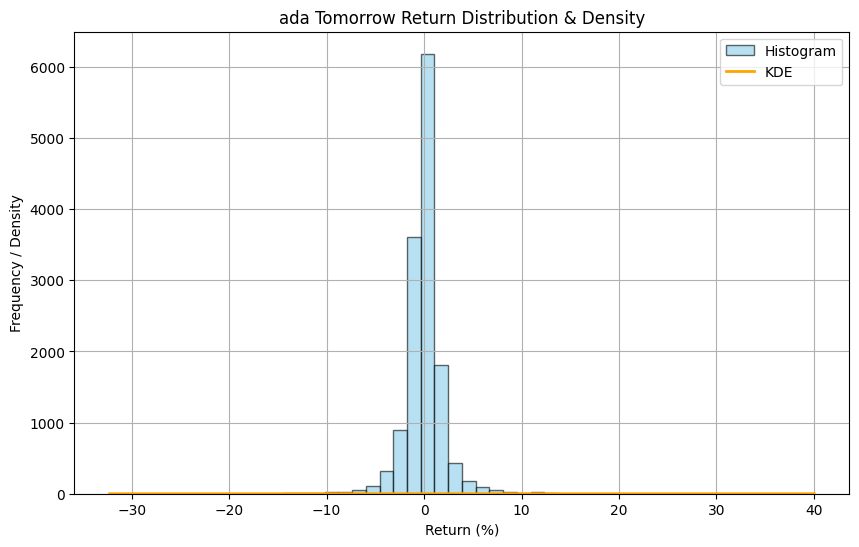

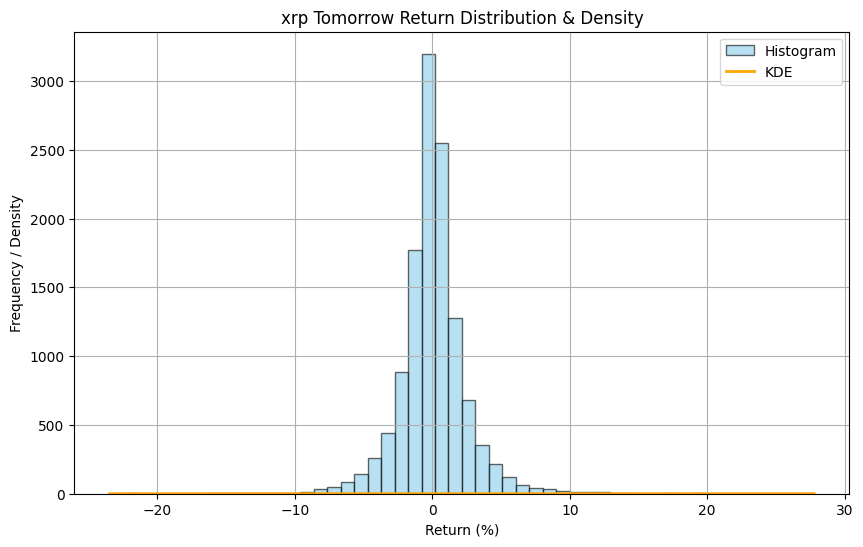

In [184]:

def plot_return_distribution(df, name):
    plt.figure(figsize=(10,6))
    plt.hist(df['next_return'].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.6, label='Histogram')
    sns.kdeplot(df['next_return'].dropna(), color='orange', lw=2, label='KDE')
    plt.title(f'{name} Tomorrow Return Distribution & Density')
    plt.xlabel('Return (%)')
    plt.ylabel('Frequency / Density')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_return_distribution(df6, 'ada')
plot_return_distribution(df7, 'xrp')

In [185]:
df6.isna().sum()

date                  0
open                  0
high                  0
low                   0
close                 0
volume                0
quote_volume          0
num_trades            0
taker_buy_volume      0
taker_buy_quote       0
type                  0
year                  0
high_low_range        0
candle_body           0
MA_7                  6
MA_30                29
ma7_ratio             6
ma30_ratio           29
moving_1d             1
volatility_7          7
volumespike           6
z_score              29
next_close            1
next_return           1
taker_buy_ratio       0
price_position        0
momentum_7            7
taker_sell_ratio      0
negative_momentum     0
down_days_7           6
volatility_14        14
volatility_3          3
label                 0
dtype: int64

In [186]:

df6.dropna(inplace=True)
df7.dropna(inplace=True)
df6.reset_index(drop=True,inplace=True)
df7.reset_index(drop=True,inplace=True)
df6.head(10)

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-05 20:00:00,0.19634,0.19664,0.19377,0.19453,8849074.9,1.726837e+06,7420,4053503.0,7.912079e+05,...,1.346836,0.458071,0.264808,0.011807,0.541929,0.0,3.0,0.489922,0.897995,Bigup
1,2020-01-06 00:00:00,0.19453,0.19756,0.19421,0.19715,13568012.9,2.661825e+06,9605,7323268.6,1.437290e+06,...,-0.355060,0.539745,0.877612,0.021238,0.460255,0.0,3.0,0.592837,1.140052,Stable
2,2020-01-06 04:00:00,0.19713,0.19739,0.19609,0.19645,9711909.3,1.911946e+06,6910,4670569.7,9.196845e+05,...,7.493001,0.480912,0.276923,0.007281,0.519088,0.0,4.0,0.605861,1.180731,Bigup
3,2020-01-06 08:00:00,0.19645,0.21394,0.19645,0.21117,74831118.0,1.556794e+07,44040,38643226.1,8.037371e+06,...,0.762419,0.516406,0.841624,0.083868,0.483594,0.0,3.0,2.050850,4.128435,Bigup
4,2020-01-06 12:00:00,0.21117,0.21624,0.20981,0.21278,44518035.9,9.492212e+06,23381,21296511.4,4.542167e+06,...,3.172291,0.478379,0.461897,0.093366,0.521621,0.0,2.0,2.043360,4.245420,Bigup
5,2020-01-06 16:00:00,0.21271,0.22032,0.21254,0.21953,46560056.4,1.014653e+07,24551,24852418.9,5.416242e+06,...,1.626201,0.533771,0.898458,0.118282,0.466229,0.0,2.0,2.130782,3.410199,Bigup
6,2020-01-06 20:00:00,0.21953,0.22396,0.21758,0.22310,44968106.7,9.930021e+06,25231,22612233.2,4.994508e+06,...,-1.492604,0.502850,0.865204,0.136294,0.497150,0.0,2.0,2.110710,1.220928,Bigdown
7,2020-01-07 00:00:00,0.22310,0.22550,0.21858,0.21977,36295390.1,8.044319e+06,19096,18687876.1,4.142970e+06,...,-0.991946,0.514883,0.171965,0.129749,0.485117,0.0,2.0,2.200916,2.376222,Bigdown
8,2020-01-07 04:00:00,0.21973,0.21986,0.21350,0.21759,31916626.8,6.884370e+06,17210,14678093.2,3.166367e+06,...,-1.222483,0.459889,0.643082,0.103677,0.540111,0.0,3.0,2.260033,1.674928,Bigdown
9,2020-01-07 08:00:00,0.21756,0.21790,0.21469,0.21493,18101841.9,3.913725e+06,11417,8729807.2,1.887567e+06,...,-3.163821,0.482261,0.074766,0.094070,0.517739,0.0,3.0,2.327839,0.250590,Bigdown


In [187]:
df7.shape

(12287, 33)

In [188]:
df6 = df6.drop(columns=cols_to_drop).reset_index(drop=True)
df7 = df7.drop(columns=cols_to_drop).reset_index(drop=True)

In [189]:
df6.drop("year",axis=1,inplace=True)
df7.drop("year",axis=1,inplace=True)

In [190]:
df6.shape
df7.shape

(12287, 21)

AVAX_DOGE

In [194]:
doge_price=pd.read_csv('all_data/doge_4h_binance.csv')
avax_price=pd.read_csv('all_data/avax_4h_binance.csv')

In [195]:
doge_price.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote
0,2020-01-01 00:00:00,0.002014,0.002036,0.002008,0.002010,9949717.0,20147.371999,185,3686153.0,7451.396274
1,2020-01-01 04:00:00,0.002020,0.002030,0.002005,0.002008,1705850.0,3429.601097,58,1051252.0,2114.120443
2,2020-01-01 08:00:00,0.002012,0.002014,0.002000,0.002012,4030898.0,8092.188479,67,3229076.0,6484.664188
3,2020-01-01 12:00:00,0.002010,0.002019,0.002007,0.002019,2448515.0,4929.761883,79,904159.0,1822.254334
4,2020-01-01 16:00:00,0.002020,0.002038,0.002019,0.002033,9386996.0,19034.325933,124,4260793.0,8644.885548


In [196]:
avax_price.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote
0,2020-09-22 04:00:00,0.8500,6.0000,0.8500,4.9096,6369386.27,3.058682e+07,65567,3281877.77,1.583425e+07
1,2020-09-22 08:00:00,4.9096,7.0000,4.8200,5.7679,12206384.53,7.256299e+07,143010,6401175.54,3.802951e+07
2,2020-09-22 12:00:00,5.7679,6.1500,4.3110,4.6699,6012583.05,3.136951e+07,84276,2803116.05,1.462521e+07
3,2020-09-22 16:00:00,4.6691,4.8902,4.0266,4.4800,3739983.85,1.681733e+07,46355,1818393.01,8.189857e+06
4,2020-09-22 20:00:00,4.4854,5.5499,4.2354,5.3193,3113545.46,1.537866e+07,36676,1563246.33,7.712972e+06


In [197]:
doge_price["date"] = pd.to_datetime(doge_price["date"])
doge_price["year"] = doge_price["date"].dt.year

In [198]:
doge_price['year'].value_counts()

year
2024    2196
2020    2195
2021    2190
2022    2190
2023    2190
2025    2190
2026     756
Name: count, dtype: int64

In [199]:
doge_price=doge_price.drop(columns="year")

In [200]:
doge_price.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'quote_volume',
       'num_trades', 'taker_buy_volume', 'taker_buy_quote'],
      dtype='object')

In [201]:
doge_price.isna().sum()

date                0
open                0
high                0
low                 0
close               0
volume              0
quote_volume        0
num_trades          0
taker_buy_volume    0
taker_buy_quote     0
dtype: int64

In [202]:
doge_price.duplicated().sum()

np.int64(0)

In [203]:
avax_price["date"] = pd.to_datetime(avax_price["date"])

In [204]:
avax_price.duplicated().sum()

np.int64(0)

In [205]:
doge_price['type'] = 'DOGE'

In [206]:

doge_price.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,type
0,2020-01-01 00:00:00,0.002014,0.002036,0.002008,0.002010,9949717.0,20147.371999,185,3686153.0,7451.396274,DOGE
1,2020-01-01 04:00:00,0.002020,0.002030,0.002005,0.002008,1705850.0,3429.601097,58,1051252.0,2114.120443,DOGE
2,2020-01-01 08:00:00,0.002012,0.002014,0.002000,0.002012,4030898.0,8092.188479,67,3229076.0,6484.664188,DOGE
3,2020-01-01 12:00:00,0.002010,0.002019,0.002007,0.002019,2448515.0,4929.761883,79,904159.0,1822.254334,DOGE
4,2020-01-01 16:00:00,0.002020,0.002038,0.002019,0.002033,9386996.0,19034.325933,124,4260793.0,8644.885548,DOGE


In [207]:

avax_price['type'] = 'AVAX'

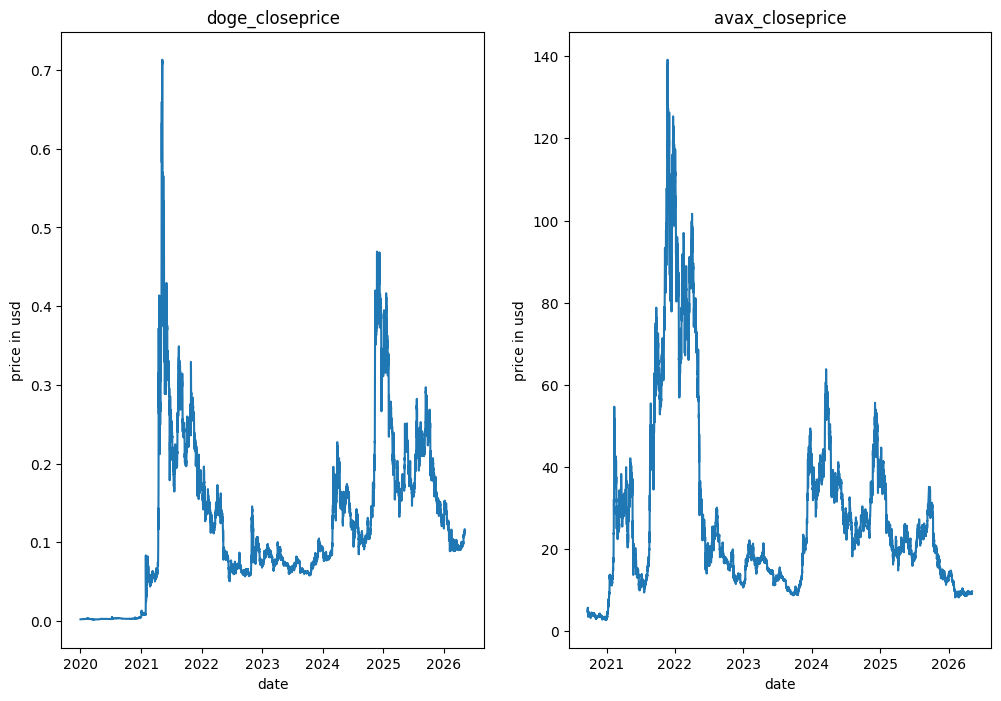

In [208]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.lineplot(x='date',data=doge_price,y='close')
plt.title("doge_closeprice")
plt.ylabel("price in usd")
plt.subplot(1,2,2)
sns.lineplot(x='date',data=avax_price,y='close')
plt.title("avax_closeprice")
plt.ylabel("price in usd")
plt.show()

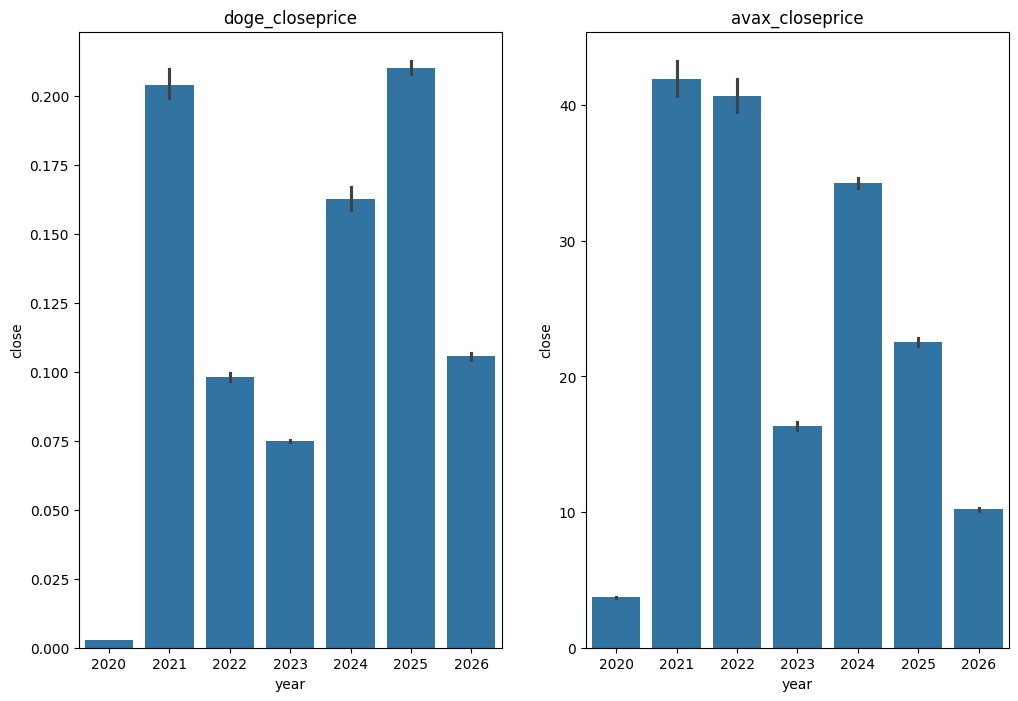

In [209]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
doge_price["year"]=doge_price["date"].dt.year
sns.barplot(x='year',data=doge_price,y='close')
plt.title("doge_closeprice")
plt.subplot(1,2,2)
avax_price["year"]=avax_price["date"].dt.year
sns.barplot(x='year',data=avax_price,y='close')
plt.title("avax_closeprice")
plt.show()

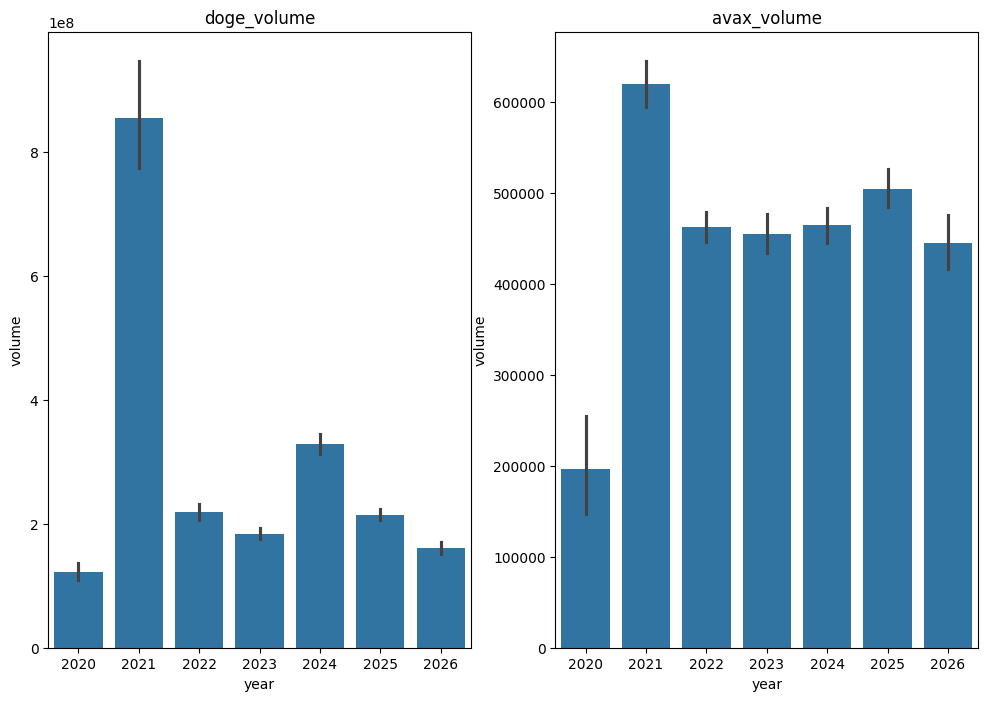

In [210]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
doge_price["year"]=doge_price["date"].dt.year
sns.barplot(x='year',data=doge_price,y='volume')
plt.title("doge_volume")
plt.subplot(1,2,2)
df2["year"]=df2["date"].dt.year
sns.barplot(x='year',data=avax_price,y='volume')
plt.title("avax_volume")
plt.show()

In [211]:
doge_price[['open','high','low','close','volume','quote_volume']].describe()

,open,high,low,close,volume,quote_volume
count,13907.000000,13907.000000,13907.000000,13907.000000,1.390700e+04,1.390700e+04
mean,0.124349,0.126623,0.121990,0.124357,3.119656e+08,4.984312e+07
std,0.099778,0.102426,0.097037,0.099772,8.920042e+08,1.587398e+08
min,0.001484,0.001579,0.001135,0.001491,1.705850e+06,3.429601e+03
25%,0.063023,0.063630,0.062360,0.063028,7.436122e+07,5.043428e+06
50%,0.096430,0.097800,0.095070,0.096440,1.376867e+08,1.453634e+07
75%,0.172905,0.175530,0.170345,0.172885,2.792507e+08,3.945949e+07
max,0.713150,0.739950,0.696740,0.713150,3.188358e+10,5.427626e+09


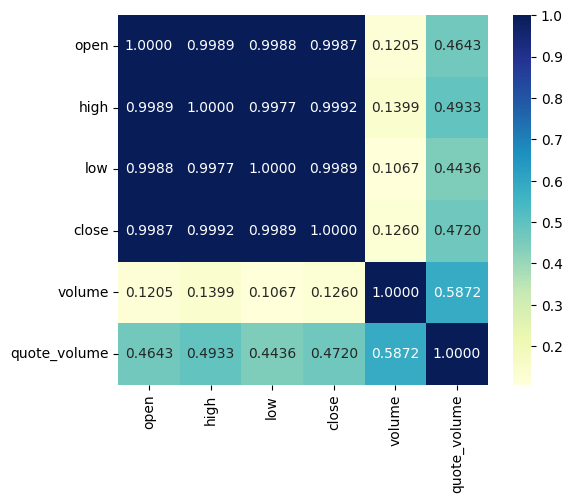

In [212]:
corr1=doge_price[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr1,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

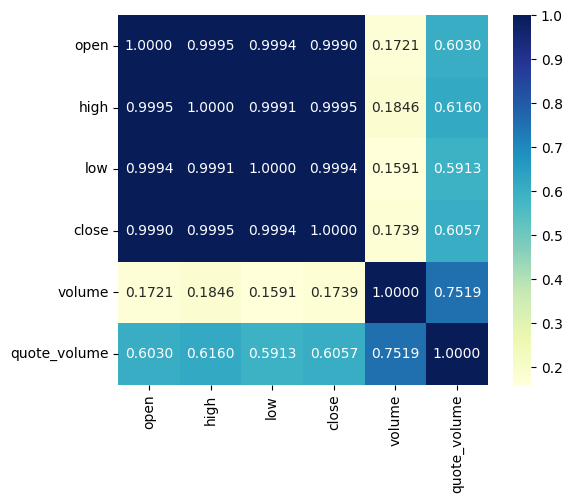

In [213]:
corr2=avax_price[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr2,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

In [214]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025]:
    doge_year = doge_price[doge_price['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=doge_year['date'],
        open=doge_year['open'],
        high=doge_year['high'],
        low=doge_year['low'],
        close=doge_year['close']
    )])

    fig.update_layout(title=f'Doge Chart - {year}')
    fig.show()"""

"for year in [2020, 2021, 2022, 2023, 2024,2025]:\n    doge_year = doge_price[doge_price['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=doge_year['date'],\n        open=doge_year['open'],\n        high=doge_year['high'],\n        low=doge_year['low'],\n        close=doge_year['close']\n    )])\n\n    fig.update_layout(title=f'Doge Chart - {year}')\n    fig.show()"

In [215]:
"""import plotly.graph_objects as go

years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
}
for year, months in years_months.items():
    doge_filtered = doge_price[(doge_price['date'].dt.year == year) & (doge_price['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=doge_filtered['date'],
        open=doge_filtered['open'],
        high=doge_filtered['high'],
        low=doge_filtered['low'],
        close=doge_filtered['close']
    )])

    fig.update_layout(title=f'Doge Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()"""

"import plotly.graph_objects as go\n\nyears_months = {\n    2020: [3, 8, 12],\n    2021: [1, 4, 11],\n    2022: [1, 5, 11],\n    2023: [1, 3, 10],\n    2024: [1, 3, 11],\n}\nfor year, months in years_months.items():\n    doge_filtered = doge_price[(doge_price['date'].dt.year == year) & (doge_price['date'].dt.month.isin(months))]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=doge_filtered['date'],\n        open=doge_filtered['open'],\n        high=doge_filtered['high'],\n        low=doge_filtered['low'],\n        close=doge_filtered['close']\n    )])\n\n    fig.update_layout(title=f'Doge Candlestick - {year} (Jan, Jun, Dec)')\n    fig.show()"

In [216]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025]:
    avax_year = avax_price[avax_price['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=avax_year['date'],
        open=avax_year['open'],
        high=avax_year['high'],
        low=avax_year['low'],
        close=avax_year['close']
    )])

    fig.update_layout(title=f'Avex Chart - {year}')
    fig.show()"""

"for year in [2020, 2021, 2022, 2023, 2024,2025]:\n    avax_year = avax_price[avax_price['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=avax_year['date'],\n        open=avax_year['open'],\n        high=avax_year['high'],\n        low=avax_year['low'],\n        close=avax_year['close']\n    )])\n\n    fig.update_layout(title=f'Avex Chart - {year}')\n    fig.show()"

In [217]:
"""import plotly.graph_objects as go

years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
}
for year, months in years_months.items():
    avax_filtered = avax_price[(avax_price['date'].dt.year == year) & (avax_price['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=avax_filtered['date'],
        open=avax_filtered['open'],
        high=avax_filtered['high'],
        low=avax_filtered['low'],
        close=avax_filtered['close']
    )])

    fig.update_layout(title=f'Avex- {year} (Jan, Jun, Dec)')
    fig.show()"""

"import plotly.graph_objects as go\n\nyears_months = {\n    2020: [3, 8, 12],\n    2021: [1, 4, 11],\n    2022: [1, 5, 11],\n    2023: [1, 3, 10],\n    2024: [1, 3, 11],\n}\nfor year, months in years_months.items():\n    avax_filtered = avax_price[(avax_price['date'].dt.year == year) & (avax_price['date'].dt.month.isin(months))]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=avax_filtered['date'],\n        open=avax_filtered['open'],\n        high=avax_filtered['high'],\n        low=avax_filtered['low'],\n        close=avax_filtered['close']\n    )])\n\n    fig.update_layout(title=f'Avex- {year} (Jan, Jun, Dec)')\n    fig.show()"

In [218]:
doge_price["candle_body"]=doge_price['close']-doge_price['open']/ doge_price['open']
avax_price['candle_body']=avax_price['close']-avax_price['open'] / avax_price['open']

In [219]:
doge_price['high_low_range']=doge_price['high']-doge_price['low']/ doge_price['close']
avax_price['high_low_range']=avax_price['high']-avax_price['low']/ avax_price['close']

In [220]:
doge_price['MA_7']=doge_price['close'].rolling(window=7).mean()
avax_price['MA_7']=avax_price['close'].rolling(window=7).mean()

In [221]:
doge_price['MA_30']=doge_price['close'].rolling(window=30).mean()
avax_price['MA_30']=avax_price['close'].rolling(window=30).mean()

In [222]:
doge_price['ma7_ratio'] = doge_price['close'] / doge_price['MA_7'] - 1
doge_price['ma30_ratio'] = doge_price['close'] / doge_price['MA_30'] - 1


In [223]:
avax_price['ma7_ratio'] = avax_price['close'] / avax_price['MA_7'] - 1
avax_price['ma30_ratio'] = avax_price['close'] / avax_price['MA_30']-1

In [224]:
doge_price['moving_1d'] = doge_price['close'].pct_change() * 100
avax_price['moving_1d'] = avax_price['close'].pct_change() * 100

In [225]:
doge_price["volatility_7"] = doge_price["moving_1d"].rolling(window=7).std()
avax_price["volatility_7"] = avax_price["moving_1d"].rolling(window=7).std()

In [226]:
doge_price["volume_MA7"] = doge_price["volume"].rolling(window=7).mean()
doge_price["volumespike"] = doge_price["volume"] / doge_price["volume_MA7"]
avax_price["volume_MA7"] = avax_price["volume"].rolling(window=7).mean()
avax_price["volumespike"] = avax_price["volume"] / avax_price["volume_MA7"]

In [227]:
doge_price.drop(columns='volume_MA7',inplace=True)
avax_price.drop(columns='volume_MA7',inplace=True)

In [228]:
doge_price["rolling_mean_30"] = doge_price["close"].rolling(window=30).mean()
doge_price["rolling_std_30"]  = doge_price["close"].rolling(window=30).std()
doge_price["z_score"] = (doge_price["close"] - doge_price["rolling_mean_30"]) / doge_price["rolling_std_30"]

avax_price["rolling_mean_30"] = avax_price["close"].rolling(window=30).mean()
avax_price["rolling_std_30"]  = avax_price["close"].rolling(window=30).std()
avax_price["z_score"] = (avax_price["close"] - avax_price["rolling_mean_30"]) / avax_price["rolling_std_30"]

In [229]:
doge_price.drop(columns='rolling_mean_30',inplace=True)
avax_price.drop(columns='rolling_mean_30',inplace=True)
doge_price.drop(columns='rolling_std_30',inplace=True)
avax_price.drop(columns='rolling_std_30',inplace=True)

In [230]:
doge_price['next_close'] = doge_price['close'].shift(-1)
doge_price['next_return'] = (doge_price['next_close'] - doge_price['close']) / doge_price['close'] * 100

avax_price['next_close'] = avax_price['close'].shift(-1)
avax_price['next_return'] = (avax_price['next_close'] - avax_price['close']) / avax_price['close'] * 100

In [231]:
doge_price['taker_buy_ratio'] = doge_price['taker_buy_volume'] / doge_price['volume']
doge_price['price_position']  = (doge_price['close'] - doge_price['low']) / (doge_price['high'] - doge_price['low'])
doge_price['momentum_7']      = doge_price['close'] / doge_price['close'].shift(7) - 1

avax_price['taker_buy_ratio'] = avax_price['taker_buy_volume'] / avax_price['volume']
avax_price['price_position']  = (avax_price['close'] - avax_price['low']) / (avax_price['high'] - avax_price['low'])
avax_price['momentum_7']      = avax_price['close'] / avax_price['close'].shift(7) - 1

In [232]:
doge_price['taker_sell_ratio']  = 1 - doge_price['taker_buy_ratio']  # bearish pressure
doge_price['negative_momentum'] = doge_price['momentum_7'].apply(lambda x: x if x < 0 else 0)   # negative side
doge_price['down_days_7']       = (doge_price['moving_1d'] < 0).rolling(7).sum()  # count down days

avax_price['taker_sell_ratio']  = 1 - avax_price['taker_buy_ratio']  # bearish pressure
avax_price['negative_momentum']=avax_price['momentum_7'].apply(lambda x: x if x<0 else 0) # negative side
avax_price['down_days_7']       = (avax_price['moving_1d'] < 0).rolling(7).sum()  # count down days

In [233]:
doge_price['volatility_14'] = doge_price['moving_1d'].rolling(14).std()
doge_price['volatility_3']  = doge_price['moving_1d'].rolling(3).std()
avax_price['volatility_14'] = avax_price['moving_1d'].rolling(14).std()
avax_price['volatility_3']  = avax_price['moving_1d'].rolling(3).std()

In [234]:
q_low = avax_price['next_return'].quantile(0.30)
q_high = avax_price['next_return'].quantile(0.70)
avax_price['label'] = avax_price['next_return'].apply(lambda x: 'Bigup' if x > q_high else ('Bigdown' if x < q_low else 'Stable'))

q_low = doge_price['next_return'].quantile(0.30)
q_high = doge_price['next_return'].quantile(0.70)
doge_price['label'] = doge_price['next_return'].apply(lambda x: 'Bigup' if x > q_high else ('Bigdown' if x < q_low else 'Stable'))

In [235]:
doge_price.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-01 00:00:00,0.002014,0.002036,0.002008,0.002010,9949717.0,20147.371999,185,3686153.0,7451.396274,...,-0.089566,0.370478,0.050725,NaN,0.629522,0.0,NaN,NaN,NaN,Stable
1,2020-01-01 04:00:00,0.002020,0.002030,0.002005,0.002008,1705850.0,3429.601097,58,1051252.0,2114.120443,...,0.204193,0.616263,0.129412,NaN,0.383737,0.0,NaN,NaN,NaN,Stable
2,2020-01-01 08:00:00,0.002012,0.002014,0.002000,0.002012,4030898.0,8092.188479,67,3229076.0,6484.664188,...,0.352883,0.801081,0.881481,NaN,0.198919,0.0,NaN,NaN,NaN,Stable
3,2020-01-01 12:00:00,0.002010,0.002019,0.002007,0.002019,2448515.0,4929.761883,79,904159.0,1822.254334,...,0.663662,0.369268,1.000000,NaN,0.630732,0.0,NaN,NaN,0.225153,Bigup
4,2020-01-01 16:00:00,0.002020,0.002038,0.002019,0.002033,9386996.0,19034.325933,124,4260793.0,8644.885548,...,-0.393604,0.453904,0.696809,NaN,0.546096,0.0,NaN,NaN,0.234451,Stable


In [236]:
from scipy.stats import skew, kurtosis
doge_price = doge_price.dropna(subset=['next_return'])
skew2=skew(doge_price['next_return'])
print(skew2)

avax_price = avax_price.dropna(subset=['next_return'])
skew21=skew(avax_price['next_return'])
print(skew21)

kurtosis1=kurtosis(doge_price['next_return'])
kurtosis2=kurtosis(avax_price['next_return'])
kurtosis1,kurtosis2

9.296192936562823
0.522960435324845


(np.float64(351.38026320954054), np.float64(10.009227426821003))

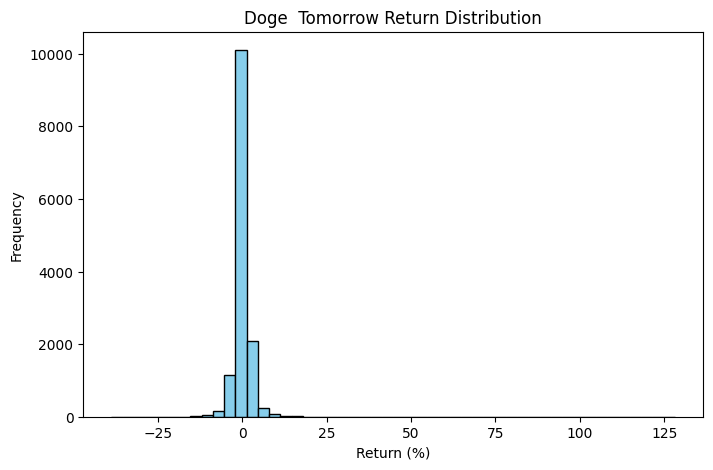

In [237]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(doge_price['next_return'], bins=50, color='skyblue', edgecolor='black')
plt.title('Doge  Tomorrow Return Distribution')
plt.xlabel('Return (%)')
plt.ylabel('Frequency')
plt.show()

C:\Users\ibrah\AppData\Local\Temp\ipykernel_28696\2868592087.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(doge_price['next_return'], shade=True, color='orange')


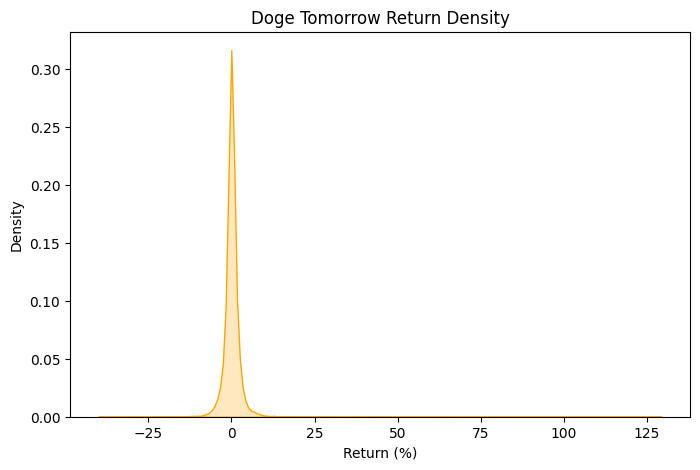

In [239]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(doge_price['next_return'], shade=True, color='orange')
plt.title('Doge Tomorrow Return Density')
plt.xlabel('Return (%)')
plt.show()

C:\Users\ibrah\AppData\Local\Temp\ipykernel_28696\4200716364.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(doge_price['next_return'], shade=True, color='lightblue')


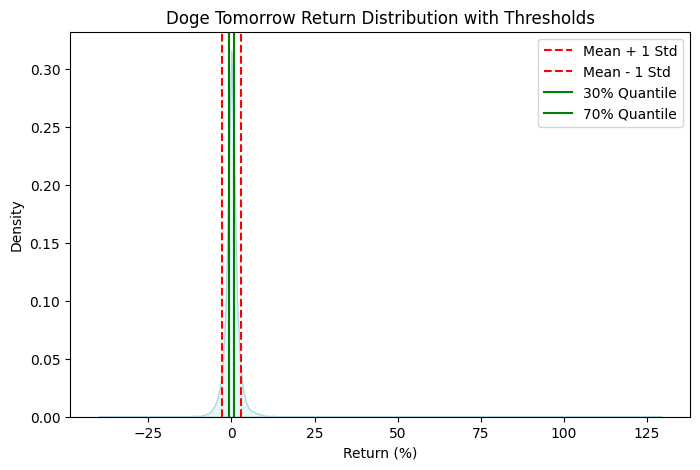

In [240]:
mean = doge_price['next_return'].mean()
std = doge_price['next_return'].std()
q_low = doge_price['next_return'].quantile(0.3)
q_high = doge_price['next_return'].quantile(0.7)

plt.figure(figsize=(8,5))
sns.kdeplot(doge_price['next_return'], shade=True, color='lightblue')

plt.axvline(mean + std, color='red', linestyle='--', label='Mean + 1 Std')
plt.axvline(mean - std, color='red', linestyle='--', label='Mean - 1 Std')

plt.axvline(q_low, color='green', linestyle='-', label='30% Quantile')
plt.axvline(q_high, color='green', linestyle='-', label='70% Quantile')

plt.title('Doge Tomorrow Return Distribution with Thresholds')
plt.xlabel('Return (%)')
plt.legend()
plt.show()

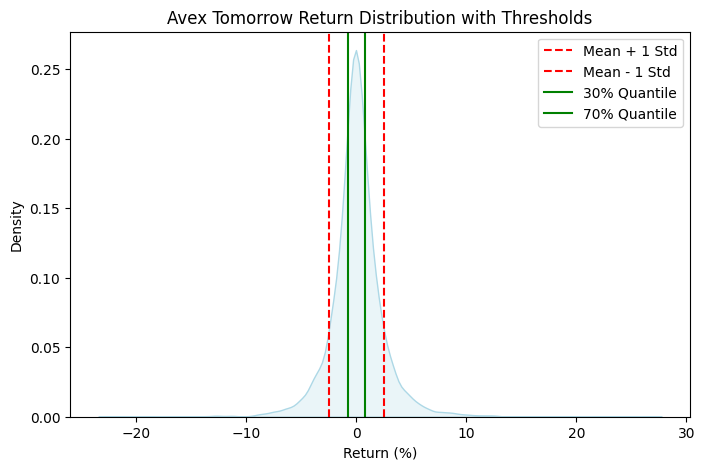

In [241]:

mean = avax_price['next_return'].mean()
std = avax_price['next_return'].std()
q_low = avax_price['next_return'].quantile(0.3)
q_high = avax_price['next_return'].quantile(0.7)

plt.figure(figsize=(8,5))
sns.kdeplot(avax_price['next_return'], fill=True, color='lightblue')

# Mean ± std thresholds
plt.axvline(mean + std, color='red', linestyle='--', label='Mean + 1 Std')
plt.axvline(mean - std, color='red', linestyle='--', label='Mean - 1 Std')

# Quantile thresholds
plt.axvline(q_low, color='green', linestyle='-', label='30% Quantile')
plt.axvline(q_high, color='green', linestyle='-', label='70% Quantile')

plt.title('Avex Tomorrow Return Distribution with Thresholds')
plt.xlabel('Return (%)')
plt.legend()
plt.show()

In [242]:
doge_price[30:35]

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
30,2020-01-06 00:00:00,0.002072,0.002110,0.002069,0.002105,11324749.0,23756.529039,312,7140668.0,14980.439295,...,-0.669993,0.630537,0.858881,0.022644,0.369463,0.0,2.0,0.564644,1.147085,Bigdown
31,2020-01-06 04:00:00,0.002108,0.002116,0.002086,0.002090,12295896.0,25765.964106,185,5835741.0,12229.908074,...,0.612323,0.474609,0.133333,0.015349,0.525391,0.0,3.0,0.620878,1.342083,Stable
32,2020-01-06 08:00:00,0.002090,0.002120,0.002087,0.002103,17003861.0,35780.399590,275,8095559.0,17042.608958,...,0.375618,0.476101,0.501511,0.013737,0.523899,0.0,3.0,0.611367,1.179688,Stable
33,2020-01-06 12:00:00,0.002106,0.002129,0.002102,0.002111,29447535.0,62213.154867,478,20348402.0,43008.674520,...,-0.341054,0.691005,0.328413,0.022374,0.308995,0.0,2.0,0.611992,0.682357,Stable
34,2020-01-06 16:00:00,0.002109,0.002115,0.002098,0.002104,13441560.0,28311.847368,295,6460629.0,13608.671444,...,1.449689,0.480646,0.362069,0.014906,0.519354,0.0,3.0,0.626160,0.496417,Bigup


In [243]:
doge_price.isna().sum()

date                  0
open                  0
high                  0
low                   0
close                 0
volume                0
quote_volume          0
num_trades            0
taker_buy_volume      0
taker_buy_quote       0
type                  0
year                  0
candle_body           0
high_low_range        0
MA_7                  6
MA_30                29
ma7_ratio             6
ma30_ratio           29
moving_1d             1
volatility_7          7
volumespike           6
z_score              29
next_close            0
next_return           0
taker_buy_ratio       0
price_position        0
momentum_7            7
taker_sell_ratio      0
negative_momentum     0
down_days_7           6
volatility_14        14
volatility_3          3
label                 0
dtype: int64

In [244]:
doge_price.dropna(inplace=True)
avax_price.dropna(inplace=True)

In [245]:
doge_price.reset_index(drop=True,inplace=True)
avax_price.reset_index(drop=True,inplace=True)

In [246]:
doge_price.drop(columns='year',axis=1,inplace=True)

In [247]:
avax_price.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-09-27 00:00:00,4.5214,4.7134,4.5106,4.5713,356543.72,1.638612e+06,6414,180752.52,830393.988581,...,-4.219806,0.506958,0.299310,-0.030148,0.493042,-0.030148,4.0,4.335621,2.797051,Bigdown
1,2020-09-27 04:00:00,4.5713,4.5900,4.3103,4.3784,223989.17,9.948973e+05,4829,90493.82,403321.262656,...,-1.950484,0.404010,0.243475,-0.034744,0.595990,-0.034744,4.0,3.368977,2.702848,Bigdown
2,2020-09-27 08:00:00,4.3880,4.3956,4.2500,4.2930,199226.29,8.596472e+05,3336,87393.83,377148.468196,...,3.028185,0.438666,0.295330,-0.082692,0.561334,-0.082692,5.0,3.351469,2.687726,Bigup
3,2020-09-27 12:00:00,4.2930,4.4232,4.1068,4.4230,396464.23,1.682948e+06,5332,221845.28,945027.407459,...,-0.644359,0.559559,0.999368,-0.031021,0.440441,-0.031021,4.0,3.455806,3.707433,Stable
4,2020-09-27 16:00:00,4.4170,4.5000,4.3566,4.3945,170399.44,7.533382e+05,3082,91013.61,402596.275878,...,5.777677,0.534119,0.264296,-0.016890,0.465881,-0.016890,4.0,3.250394,2.581366,Bigup


In [248]:
doge_price.head()

,date,open,high,low,close,volume,quote_volume,num_trades,taker_buy_volume,taker_buy_quote,...,next_return,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-05 20:00:00,0.002082,0.002084,0.002050,0.002070,13706218.0,28385.507370,233,5954483.0,12327.497004,...,1.686316,0.434437,0.571848,0.007105,0.565563,0.0,2.0,0.438202,0.591286,Bigup
1,2020-01-06 00:00:00,0.002072,0.002110,0.002069,0.002105,11324749.0,23756.529039,312,7140668.0,14980.439295,...,-0.669993,0.630537,0.858881,0.022644,0.369463,0.0,2.0,0.564644,1.147085,Bigdown
2,2020-01-06 04:00:00,0.002108,0.002116,0.002086,0.002090,12295896.0,25765.964106,185,5835741.0,12229.908074,...,0.612323,0.474609,0.133333,0.015349,0.525391,0.0,3.0,0.620878,1.342083,Stable
3,2020-01-06 08:00:00,0.002090,0.002120,0.002087,0.002103,17003861.0,35780.399590,275,8095559.0,17042.608958,...,0.375618,0.476101,0.501511,0.013737,0.523899,0.0,3.0,0.611367,1.179688,Stable
4,2020-01-06 12:00:00,0.002106,0.002129,0.002102,0.002111,29447535.0,62213.154867,478,20348402.0,43008.674520,...,-0.341054,0.691005,0.328413,0.022374,0.308995,0.0,2.0,0.611992,0.682357,Stable


In [249]:
avax_price.drop("year",axis=1,inplace=True)

In [251]:
doge_price = doge_price.drop(columns=cols_to_drop).reset_index(drop=True)
avax_price = avax_price.drop(columns=cols_to_drop).reset_index(drop=True)

In [252]:
combined=pd.concat([doge_price,avax_price],ignore_index=True)
combined.to_csv("avax_dodge_6years_binance.csv",index=False)

In [253]:
df9=pd.read_csv("avax_dodge_6years_binance.csv")

In [254]:
df9.head()

,date,num_trades,taker_buy_volume,type,candle_body,high_low_range,ma7_ratio,ma30_ratio,moving_1d,volatility_7,...,z_score,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-05 20:00:00,233,5954483.0,DOGE,-0.997930,-0.988494,0.000421,0.019134,-0.605129,0.497531,...,1.343001,0.434437,0.571848,0.007105,0.565563,0.0,2.0,0.438202,0.591286,Bigup
1,2020-01-06 00:00:00,312,7140668.0,DOGE,-0.997896,-0.981116,0.014028,0.034710,1.686316,0.780160,...,2.233479,0.630537,0.858881,0.022644,0.369463,0.0,2.0,0.564644,1.147085,Bigdown
2,2020-01-06 04:00:00,185,5835741.0,DOGE,-0.997910,-0.995970,0.005048,0.026390,-0.669993,0.864788,...,1.636964,0.474609,0.133333,0.015349,0.525391,0.0,3.0,0.620878,1.342083,Stable
3,2020-01-06 08:00:00,275,8095559.0,DOGE,-0.997897,-0.989988,0.009227,0.031135,0.612323,0.849776,...,1.833125,0.476101,0.501511,0.013737,0.523899,0.0,3.0,0.611367,1.179688,Stable
4,2020-01-06 12:00:00,478,20348402.0,DOGE,-0.997889,-0.993655,0.009820,0.033455,0.375618,0.797064,...,1.858827,0.691005,0.328413,0.022374,0.308995,0.0,2.0,0.611992,0.682357,Stable


In [255]:
df9.shape

(26164, 21)

In [256]:
doge_price.shape

(13877, 21)

In [257]:

avax_price.shape

(12287, 21)

In [258]:
combined_final=pd.concat([df3,df4,df5,df6,df7,df9],ignore_index=True)
combined_final.to_csv("final_crypto.csv",index=False)

In [259]:
df10=pd.read_csv("final_crypto.csv")

In [260]:
df10.shape

(106498, 21)

In [261]:
df10.head()

,date,num_trades,taker_buy_volume,type,candle_body,high_low_range,ma7_ratio,ma30_ratio,moving_1d,volatility_7,...,z_score,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-05 20:00:00,56284,2918.176154,BTC,7357.75,7444.005538,-0.009158,0.013047,-1.147077,0.907270,...,0.655265,0.445457,0.320866,0.003261,0.554543,0.0,4.0,0.634257,0.884746,Bigup
1,2020-01-06 00:00:00,90571,7253.706938,BTC,7539.90,7579.025745,0.011733,0.036620,2.475285,1.295897,...,1.741604,0.534215,0.832362,0.025399,0.465785,0.0,4.0,0.909539,1.899092,Bigdown
2,2020-01-06 04:00:00,44909,2533.851605,BTC,7506.91,7553.611586,0.006691,0.030677,-0.437481,1.185169,...,1.412528,0.525399,0.203208,0.004270,0.474601,0.0,5.0,0.924428,1.919602,Bigup
3,2020-01-06 08:00:00,71448,3633.641591,BTC,7543.72,7581.274948,0.010057,0.034086,0.490283,1.189660,...,1.514532,0.464225,0.498531,0.010865,0.535775,0.0,4.0,0.923365,1.488018,Stable
4,2020-01-06 12:00:00,74063,4670.265212,BTC,7518.99,7621.007254,0.004870,0.029353,-0.327779,1.169993,...,1.270947,0.507037,0.348429,0.013158,0.492963,0.0,4.0,0.934383,0.506953,Stable


In [262]:
df10[1000:2000]

,date,num_trades,taker_buy_volume,type,candle_body,high_low_range,ma7_ratio,ma30_ratio,moving_1d,volatility_7,...,z_score,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
1000,2020-06-20 16:00:00,57055,2269.910126,BTC,9285.54,9318.454904,-0.001805,-0.012232,0.288992,0.463351,...,-1.332352,0.510583,0.580497,-0.010314,0.489417,-0.010314,3.0,0.548317,0.564306,Bigup
1001,2020-06-20 20:00:00,62788,2590.922730,BTC,9357.95,9394.007746,0.005182,-0.004294,0.779731,0.473933,...,-0.466416,0.556868,0.667864,0.005542,0.443132,0.000000,2.0,0.584155,0.758453,Stable
1002,2020-06-21 00:00:00,55538,1967.870861,BTC,9370.78,9399.002950,0.005611,-0.002254,0.137088,0.473797,...,-0.261526,0.505102,0.494899,0.006611,0.494898,0.000000,2.0,0.584339,0.335879,Stable
1003,2020-06-21 04:00:00,49364,2297.631913,BTC,9367.98,9421.001380,0.004720,-0.002074,-0.029877,0.472271,...,-0.248722,0.536041,0.196058,0.004108,0.463959,0.000000,3.0,0.583568,0.427460,Stable
1004,2020-06-21 08:00:00,45087,1742.697366,BTC,9357.50,9384.262939,0.002741,-0.002654,-0.111858,0.453711,...,-0.332089,0.470404,0.506819,0.005979,0.529596,0.000000,3.0,0.476840,0.126868,Stable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2020-12-03 12:00:00,208320,6325.729194,BTC,19534.00,19535.216136,0.017271,0.038248,0.714046,0.878879,...,1.196698,0.531112,0.996208,0.021315,0.468888,0.000000,2.0,1.168859,0.181372,Bigdown
1996,2020-12-03 16:00:00,215349,5955.494174,BTC,19413.29,19597.011344,0.007069,0.028916,-0.617917,0.715131,...,0.940539,0.480870,0.545205,0.027669,0.519130,0.000000,2.0,1.174393,0.856457,Stable
1997,2020-12-03 20:00:00,159404,3269.717924,BTC,19420.90,19539.005954,0.005074,0.026234,0.039198,0.647687,...,0.909134,0.464374,0.494716,0.016795,0.535626,0.000000,2.0,1.149592,0.666001,Bigdown
1998,2020-12-04 00:00:00,161163,3713.576532,BTC,19161.62,19526.002081,-0.008039,0.010229,-1.334988,0.856965,...,0.380790,0.427655,0.098649,-0.002159,0.572345,-0.002159,3.0,1.176290,0.687311,Bigup


In [263]:
df10.isna().sum()

date                 0
num_trades           0
taker_buy_volume     0
type                 0
candle_body          0
high_low_range       0
ma7_ratio            0
ma30_ratio           0
moving_1d            0
volatility_7         0
volumespike          0
z_score              0
taker_buy_ratio      0
price_position       0
momentum_7           0
taker_sell_ratio     0
negative_momentum    0
down_days_7          0
volatility_14        0
volatility_3         0
label                0
dtype: int64

In [264]:
df10.shape

(106498, 21)

In [265]:
df10["type"].value_counts()

type
BTC     13877
ETH     13877
BNB     13877
XRP     13877
DOGE    13877
SOL     12539
ADA     12287
AVAX    12287
Name: count, dtype: int64

In [266]:
df10.isna().sum()

date                 0
num_trades           0
taker_buy_volume     0
type                 0
candle_body          0
high_low_range       0
ma7_ratio            0
ma30_ratio           0
moving_1d            0
volatility_7         0
volumespike          0
z_score              0
taker_buy_ratio      0
price_position       0
momentum_7           0
taker_sell_ratio     0
negative_momentum    0
down_days_7          0
volatility_14        0
volatility_3         0
label                0
dtype: int64

In [267]:

print("\nDistribution per coin:")
print(df10.groupby('type')['label'].value_counts())


Distribution per coin:
type  label  
ADA   Stable     4924
      Bigup      3682
      Bigdown    3681
AVAX  Stable     4924
      Bigup      3682
      Bigdown    3681
BNB   Stable     5548
      Bigup      4165
      Bigdown    4164
BTC   Stable     5544
      Bigdown    4167
      Bigup      4166
DOGE  Stable     5543
      Bigdown    4168
      Bigup      4166
ETH   Stable     5546
      Bigdown    4166
      Bigup      4165
SOL   Stable     5021
      Bigdown    3759
      Bigup      3759
XRP   Stable     5541
      Bigdown    4168
      Bigup      4168
Name: count, dtype: int64


In [268]:
df10["label"].value_counts()

label
Stable     42591
Bigdown    31954
Bigup      31953
Name: count, dtype: int64

In [269]:
pd.crosstab(df10["type"], df10["label"], normalize="index")

label,Bigdown,Bigup,Stable
type,,,
ADA,0.299585,0.299666,0.400749
AVAX,0.299585,0.299666,0.400749
BNB,0.300065,0.300137,0.399798
BTC,0.300281,0.300209,0.399510
DOGE,0.300353,0.300209,0.399438
ETH,0.300209,0.300137,0.399654
SOL,0.299785,0.299785,0.400431
XRP,0.300353,0.300353,0.399294


In [270]:

df10.head()

,date,num_trades,taker_buy_volume,type,candle_body,high_low_range,ma7_ratio,ma30_ratio,moving_1d,volatility_7,...,z_score,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
0,2020-01-05 20:00:00,56284,2918.176154,BTC,7357.75,7444.005538,-0.009158,0.013047,-1.147077,0.907270,...,0.655265,0.445457,0.320866,0.003261,0.554543,0.0,4.0,0.634257,0.884746,Bigup
1,2020-01-06 00:00:00,90571,7253.706938,BTC,7539.90,7579.025745,0.011733,0.036620,2.475285,1.295897,...,1.741604,0.534215,0.832362,0.025399,0.465785,0.0,4.0,0.909539,1.899092,Bigdown
2,2020-01-06 04:00:00,44909,2533.851605,BTC,7506.91,7553.611586,0.006691,0.030677,-0.437481,1.185169,...,1.412528,0.525399,0.203208,0.004270,0.474601,0.0,5.0,0.924428,1.919602,Bigup
3,2020-01-06 08:00:00,71448,3633.641591,BTC,7543.72,7581.274948,0.010057,0.034086,0.490283,1.189660,...,1.514532,0.464225,0.498531,0.010865,0.535775,0.0,4.0,0.923365,1.488018,Stable
4,2020-01-06 12:00:00,74063,4670.265212,BTC,7518.99,7621.007254,0.004870,0.029353,-0.327779,1.169993,...,1.270947,0.507037,0.348429,0.013158,0.492963,0.0,4.0,0.934383,0.506953,Stable


In [271]:
df10.columns.tolist()

['date',
 'num_trades',
 'taker_buy_volume',
 'type',
 'candle_body',
 'high_low_range',
 'ma7_ratio',
 'ma30_ratio',
 'moving_1d',
 'volatility_7',
 'volumespike',
 'z_score',
 'taker_buy_ratio',
 'price_position',
 'momentum_7',
 'taker_sell_ratio',
 'negative_momentum',
 'down_days_7',
 'volatility_14',
 'volatility_3',
 'label']

In [272]:
df10['date']=pd.to_datetime(df10['date'])
df10['hours']=df10['date'].dt.hour

In [273]:
df=df10.copy()



In [274]:
df=df[df["type"]!="XRP"]
df=df[df["type"]!="BTC"]

In [ ]:
df.shape

(78744, 22)

In [ ]:
df.head()

,date,num_trades,taker_buy_volume,type,candle_body,high_low_range,ma7_ratio,ma30_ratio,moving_1d,volatility_7,...,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label,hours
13877,2020-01-05 20:00:00,22032,22539.74791,ETH,135.351467,137.068569,-0.004685,0.023770,-1.884468,1.223157,...,0.479223,0.301299,0.012339,0.520777,0.0,3.0,0.912849,1.792502,Bigup,20
13878,2020-01-06 00:00:00,29327,38530.67457,ETH,139.471601,138.703192,0.019941,0.052463,3.043510,1.638357,...,0.473087,0.962578,0.039419,0.526913,0.0,3.0,1.191829,2.464251,Stable,0
13879,2020-01-06 04:00:00,14818,15428.41043,ETH,138.851502,139.002376,0.012541,0.045516,-0.444476,1.623014,...,0.483735,0.226027,0.019903,0.516265,0.0,4.0,1.204572,2.533923,Bigup,4
13880,2020-01-06 08:00:00,32092,38378.76286,ETH,141.521504,142.079288,0.026109,0.062738,1.922661,1.718406,...,0.440804,0.642353,0.040582,0.559196,0.0,3.0,1.245978,1.780716,Bigdown,8
13881,2020-01-06 12:00:00,35498,51023.28882,ETH,140.181240,142.227989,0.011023,0.050541,-0.946729,1.751498,...,0.500594,0.270531,0.037980,0.499406,0.0,3.0,1.299540,1.532373,Bigup,12


In [ ]:
train_coins = ['ETH', 'BNB', 'SOL', 'ADA']
test_coins = ['DOGE', 'AVAX']

train_df = df[df['type'].isin(train_coins)].copy()
test_df  = df[df['type'].isin(test_coins)].copy()

print("Coins in train:", train_df['type'].unique())
print("Coins in test:", test_df['type'].unique())

Coins in train: ['ETH' 'BNB' 'SOL' 'ADA']
Coins in test: ['DOGE' 'AVAX']


In [ ]:
df.columns.tolist()

['date',
 'num_trades',
 'taker_buy_volume',
 'type',
 'candle_body',
 'high_low_range',
 'ma7_ratio',
 'ma30_ratio',
 'moving_1d',
 'volatility_7',
 'volumespike',
 'z_score',
 'taker_buy_ratio',
 'price_position',
 'momentum_7',
 'taker_sell_ratio',
 'negative_momentum',
 'down_days_7',
 'volatility_14',
 'volatility_3',
 'label',
 'hours']

Train: 52580 | Test: 26164

--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.54      0.55      0.55      7849
       Bigup       0.59      0.54      0.56      7848
      Stable       0.61      0.64      0.63     10467

    accuracy                           0.58     26164
   macro avg       0.58      0.58      0.58     26164
weighted avg       0.58      0.58      0.58     26164



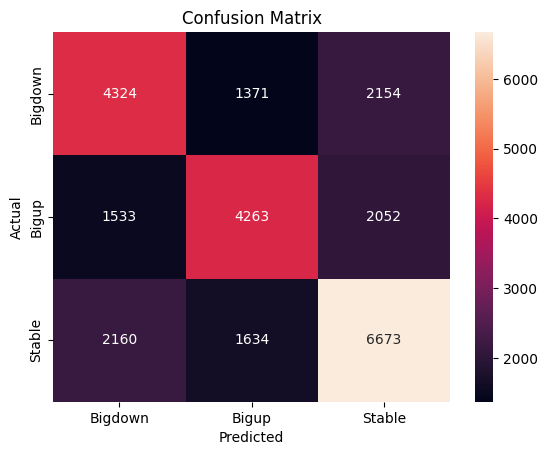

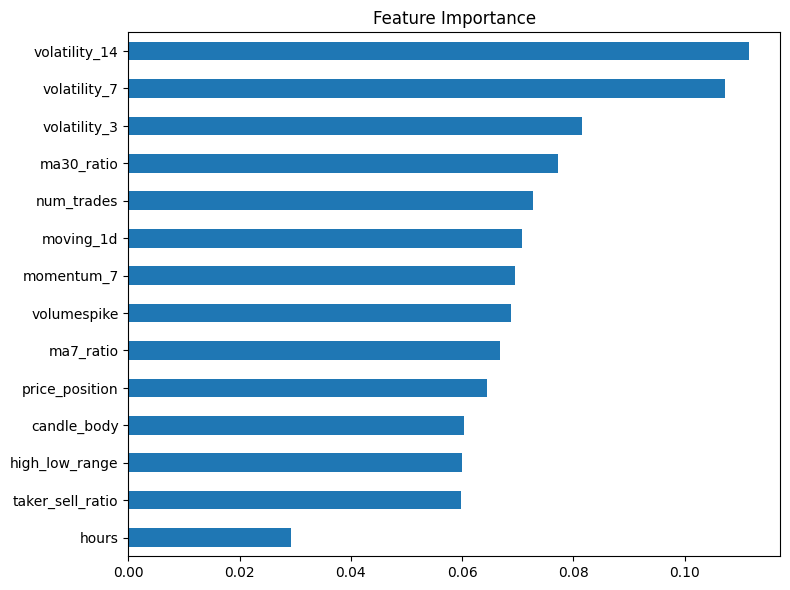

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
# Load your combined dataframe
# df = pd.read_csv("your_combined_file.csv")
from sklearn.preprocessing import LabelEncoder



# Don't encode, just map manually

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score','taker_buy_ratio','taker_buy_ratio', 'negative_momentum',
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['label']


model = RandomForestClassifier(
    n_estimators=700,
    max_depth=13,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    criterion='entropy',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
# Train
model.fit(X_train, y_train)





# Evaluate on test
test_preds = model.predict(X_test)
print("\n--- Test Results ---")
print(classification_report(y_test, test_preds, target_names=['Bigdown', 'Bigup','Stable']))

# Confusion matrix
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Bigdown', 'Bigup','Stable'],
                                     yticklabels=['Bigdown', 'Bigup','Stable'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Feature importance
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:

# Check train performance too
train_preds = model.predict(X_train)
print("--- Train Results ---")
print(classification_report(y_train, train_preds, target_names=['Bigdown', 'Bigup','Stable']))

print("--- Test Results ---")
print(classification_report(y_test, test_preds, target_names=['Bigdown', 'Bigup','Stable']))

--- Train Results ---
              precision    recall  f1-score   support

     Bigdown       0.76      0.71      0.74     15770
       Bigup       0.75      0.71      0.73     15771
      Stable       0.67      0.73      0.70     21039

    accuracy                           0.72     52580
   macro avg       0.73      0.72      0.72     52580
weighted avg       0.72      0.72      0.72     52580

--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.54      0.55      0.55      7849
       Bigup       0.59      0.54      0.56      7848
      Stable       0.61      0.64      0.63     10467

    accuracy                           0.58     26164
   macro avg       0.58      0.58      0.58     26164
weighted avg       0.58      0.58      0.58     26164



In [ ]:


# Split by rows (80/20)
split = int(len(df) * 0.80)

train_df = df.iloc[:split]
test_df  = df.iloc[split:]

# Verify
print(f"Train: {len(train_df)}")
print(f"Test:  {len(test_df)}")
print(f"Train date range: {train_df['date'].min()} → {train_df['date'].max()}")
print(f"Test date range:  {test_df['date'].min()} → {test_df['date'].max()}")
print(f"Coins in train: {train_df['type'].unique()}")
print(f"Coins in test:  {test_df['type'].unique()}")

Train: 29318
Test:  7330
Train date range: 2020-04-08 → 2026-04-25 00:00:00
Test date range:  2020-09-27 → 2026-04-25
Coins in train: ['ETH' 'BNB' 'SOL' 'ADA' 'DOGE']
Coins in test:  ['DOGE' 'AVAX']


In [ ]:
print(y_train.unique())
print(sorted(y_train.unique()))

['Bigdown' 'Bigup' 'Stable']
['Bigdown', 'Bigup', 'Stable']


In [ ]:
results_df = pd.DataFrame(results)

print(results_df)

print("\nAverage Results:")
print(results_df[['accuracy', 'macro_f1', 'weighted_f1']].mean())

  test_coin  accuracy  macro_f1  weighted_f1
0       ADA  0.779797  0.781978     0.779922
1      AVAX  0.777177  0.779060     0.777342
2       BNB  0.460380  0.383083     0.405165
3      DOGE  0.432875  0.388147     0.405686
4       ETH  0.420923  0.420425     0.425820
5       SOL  0.403897  0.404254     0.405507

Average Results:
accuracy       0.545842
macro_f1       0.526158
weighted_f1    0.533240
dtype: float64


In [ ]:
df=df[df["type"]!="BNB"]
df=df[df["type"]!="DOGE"]
df=df[df["type"]!="ETH"]
df=df[df["type"]!="SOL"]

In [ ]:
df.shape

(24574, 22)

In [ ]:
df.sort_values(by="date",ascending=False,inplace=True)

In [ ]:


# Split by rows (80/20)
split = int(len(df) * 0.80)

train_df = df.iloc[:split]
test_df  = df.iloc[split:]

# Verify
print(f"Train: {len(train_df)}")
print(f"Test:  {len(test_df)}")
print(f"Train date range: {train_df['date'].min()} → {train_df['date'].max()}")
print(f"Test date range:  {test_df['date'].min()} → {test_df['date'].max()}")
print(f"Coins in train: {train_df['type'].unique()}")
print(f"Coins in test:  {test_df['type'].unique()}")

Train: 19659
Test:  4915
Train date range: 2021-11-10 12:00:00 → 2026-05-06 16:00:00
Test date range:  2020-09-27 00:00:00 → 2021-11-10 12:00:00
Coins in train: ['AVAX' 'ADA']
Coins in test:  ['AVAX' 'ADA']


Train: 19659 | Test: 4915

--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.66      0.54      0.59      1476
       Bigup       0.62      0.61      0.61      1460
      Stable       0.60      0.68      0.64      1979

    accuracy                           0.62      4915
   macro avg       0.62      0.61      0.61      4915
weighted avg       0.62      0.62      0.62      4915



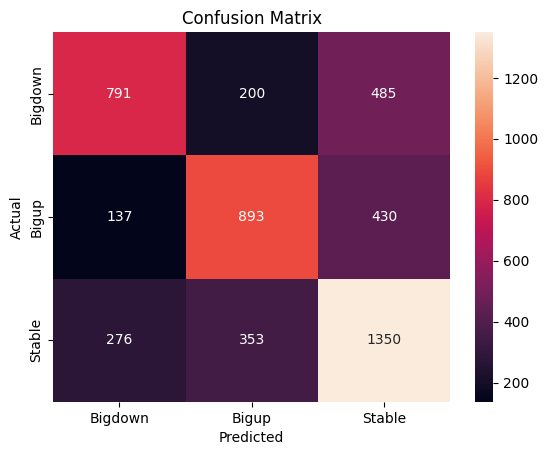

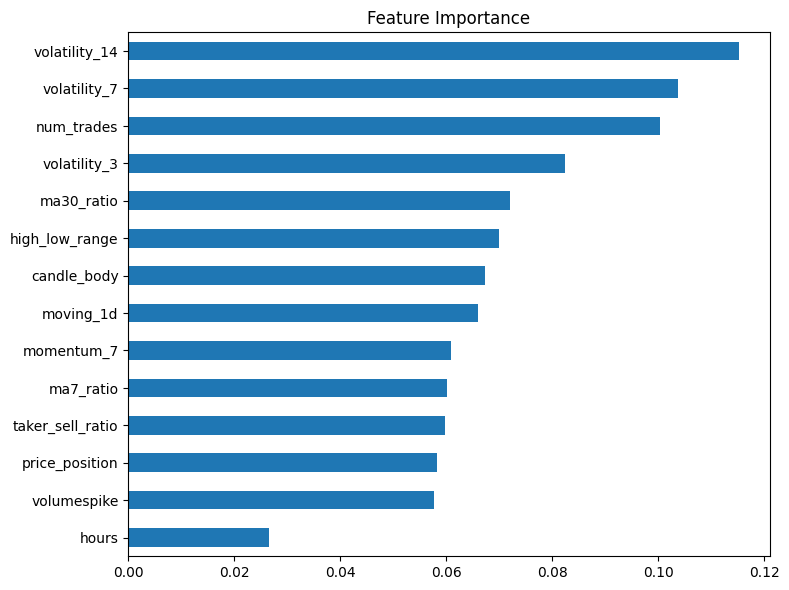

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
# Load your combined dataframe
# df = pd.read_csv("your_combined_file.csv")
from sklearn.preprocessing import LabelEncoder



# Don't encode, just map manually

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score','taker_buy_ratio','taker_buy_ratio', 'negative_momentum',
]

X=df.drop(columns=drop_cols)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    criterion='entropy',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
# Train
model.fit(X_train, y_train)





# Evaluate on test
test_preds = model.predict(X_test)
print("\n--- Test Results ---")
print(classification_report(y_test, test_preds, target_names=['Bigdown', 'Bigup','Stable']))

# Confusion matrix
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Bigdown', 'Bigup','Stable'],
                                     yticklabels=['Bigdown', 'Bigup','Stable'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Feature importance
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:

# Check train performance too
train_preds = model.predict(X_train)
print("--- Train Results ---")
print(classification_report(y_train, train_preds, target_names=['Bigdown', 'Bigup','Stable']))

print("--- Test Results ---")
print(classification_report(y_test, test_preds, target_names=['Bigdown', 'Bigup','Stable']))

--- Train Results ---
              precision    recall  f1-score   support

     Bigdown       0.83      0.73      0.78      5886
       Bigup       0.81      0.75      0.78      5904
      Stable       0.69      0.79      0.74      7869

    accuracy                           0.76     19659
   macro avg       0.78      0.76      0.76     19659
weighted avg       0.77      0.76      0.76     19659

--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.66      0.54      0.59      1476
       Bigup       0.62      0.61      0.61      1460
      Stable       0.60      0.68      0.64      1979

    accuracy                           0.62      4915
   macro avg       0.62      0.61      0.61      4915
weighted avg       0.62      0.62      0.62      4915

